# Análise Exploratória — Oportunidades em meio ao Caos

Esta etapa avalia a qualidade dos dados depois do pré-processamento e investiga padrões que podem ajudar na futura classificação de regimes de estresse e na análise de resiliência dos setores.

A pergunta principal do projeto continua sendo:

> **Dado um cenário de estresse socioeconômico, quais setores historicamente apresentaram maior resiliência e melhor relação entre retorno e risco?**

A EDA não tem como objetivo provar causalidade nem treinar o modelo final. O foco é entender a base, suas limitações e quais hipóteses fazem sentido levar para a próxima etapa.

## 1. Carregamento e configuração

O notebook procura primeiro os arquivos em `data/curated`. Se não encontrar, tenta ler o bucket `curated` do MinIO. Assim, o notebook funciona tanto localmente quanto com o armazenamento do projeto.

In [1]:
from pathlib import Path
from io import BytesIO
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Descobre a raiz do projeto quando o notebook roda dentro de notebooks/.
CWD = Path.cwd().resolve()
if (CWD / "data" / "curated").exists():
    BASE = CWD
elif (CWD.parent / "data" / "curated").exists():
    BASE = CWD.parent
else:
    BASE = CWD

CURATED = BASE / "data" / "curated"
load_dotenv(BASE / ".env")

print("Diretório do projeto:", BASE)
print("Curated local:", CURATED)

Diretório do projeto: C:\Users\Fabio\Desktop\HandsOn\handson_mack_2sem\mvp_resiliencia_dados
Curated local: C:\Users\Fabio\Desktop\HandsOn\handson_mack_2sem\mvp_resiliencia_dados\data\curated


In [2]:
def read_curated(filename: str) -> pd.DataFrame:
    local = CURATED / filename
    if local.exists():
        print(f"LOCAL  -> {local}")
        return pd.read_csv(local)

    # Fallback opcional para MinIO.
    import boto3

    endpoint = os.getenv("MINIO_ENDPOINT", "localhost:9000")
    secure = os.getenv("MINIO_SECURE", "false").lower() in {"1", "true", "yes"}
    access = os.getenv("MINIO_ROOT_USER") or os.getenv("MINIO_ACCESS_KEY")
    secret = os.getenv("MINIO_ROOT_PASSWORD") or os.getenv("MINIO_SECRET_KEY")
    bucket = os.getenv("MINIO_BUCKET_CURATED", "curated")

    if not access or not secret:
        raise FileNotFoundError(
            f"{filename} não encontrado localmente e credenciais do MinIO não estão configuradas."
        )

    s3 = boto3.client(
        "s3",
        endpoint_url=f"http{'s' if secure else ''}://{endpoint}",
        aws_access_key_id=access,
        aws_secret_access_key=secret,
        region_name="us-east-1",
    )
    obj = s3.get_object(Bucket=bucket, Key=filename)
    print(f"MINIO  -> s3://{bucket}/{filename}")
    return pd.read_csv(BytesIO(obj["Body"].read()))

ref = read_curated("dataset_monthly_reference.csv")
mvp = read_curated("dataset_mvp.csv")
complete = read_curated("dataset_mvp_complete.csv")

for df in (ref, mvp, complete):
    df["date"] = pd.to_datetime(df["date"])
    df.sort_values("date", inplace=True)
    df.reset_index(drop=True, inplace=True)

print("\nShapes:")
print("reference:", ref.shape)
print("mvp:      ", mvp.shape)
print("complete: ", complete.shape)

LOCAL  -> C:\Users\Fabio\Desktop\HandsOn\handson_mack_2sem\mvp_resiliencia_dados\data\curated\dataset_monthly_reference.csv
LOCAL  -> C:\Users\Fabio\Desktop\HandsOn\handson_mack_2sem\mvp_resiliencia_dados\data\curated\dataset_mvp.csv
LOCAL  -> C:\Users\Fabio\Desktop\HandsOn\handson_mack_2sem\mvp_resiliencia_dados\data\curated\dataset_mvp_complete.csv

Shapes:
reference: (176, 31)
mvp:       (176, 34)
complete:  (139, 34)


## 2. Entendimento dos três datasets

- **`dataset_monthly_reference.csv`**: dados alinhados ao mês de referência. É o principal dataset para gráficos históricos e EDA.
- **`dataset_mvp.csv`**: contém os lags aplicados no pré-processamento para reduzir *look-ahead bias*. É a referência para avaliar futuras features do modelo.
- **`dataset_mvp_complete.csv`**: mantém somente meses em que todas as variáveis principais estão preenchidas. É útil para algumas análises conjuntas, mas não deve limitar toda a EDA.

In [3]:
def dataset_summary(name, df):
    return {
        "dataset": name,
        "linhas": len(df),
        "colunas": df.shape[1],
        "inicio": df["date"].min(),
        "fim": df["date"].max(),
        "duplicadas_data": int(df["date"].duplicated().sum()),
        "missing_total": int(df.isna().sum().sum()),
    }

summary_datasets = pd.DataFrame([
    dataset_summary("monthly_reference", ref),
    dataset_summary("mvp", mvp),
    dataset_summary("mvp_complete", complete),
])
display(summary_datasets)

,dataset,linhas,colunas,inicio,fim,duplicadas_data,missing_total
0,monthly_reference,176,31,2012-01-31,2026-08-31,0,199
1,mvp,176,34,2012-01-31,2026-08-31,0,218
2,mvp_complete,139,34,2015-01-31,2026-07-31,0,7


### Atenção ao último mês

O pré-processamento deve trabalhar apenas com meses completos. Como proteção adicional, a EDA identifica o último mês calendário já encerrado e evita usar um mês ainda em andamento nas comparações temporais.

In [4]:
today = pd.Timestamp.today().normalize()
last_closed_month = today.to_period("M").start_time - pd.Timedelta(days=1)
last_closed_month = last_closed_month.to_period("M").to_timestamp("M")

print("Hoje:", today.date())
print("Último mês calendário encerrado:", last_closed_month.date())

for name, df in [("reference", ref), ("mvp", mvp), ("complete", complete)]:
    future_rows = df[df["date"] > last_closed_month]
    print(f"{name}: {len(future_rows)} linha(s) após o último mês encerrado")

# Bases de análise sem mês calendário incompleto.
ref_eda = ref[ref["date"] <= last_closed_month].copy()
mvp_eda = mvp[mvp["date"] <= last_closed_month].copy()
complete_eda = complete[complete["date"] <= last_closed_month].copy()

Hoje: 2026-09-02
Último mês calendário encerrado: 2026-08-31
reference: 0 linha(s) após o último mês encerrado
mvp: 0 linha(s) após o último mês encerrado
complete: 0 linha(s) após o último mês encerrado


## 3. Qualidade dos dados

Aqui verificamos tipos, missing values, duplicidades e continuidade mensal. Missing não será preenchido automaticamente: primeiro precisamos entender por que existe.

In [5]:
quality = pd.DataFrame({
    "coluna": ref_eda.columns,
    "tipo": [str(ref_eda[c].dtype) for c in ref_eda.columns],
    "non_null": [int(ref_eda[c].notna().sum()) for c in ref_eda.columns],
    "missing": [int(ref_eda[c].isna().sum()) for c in ref_eda.columns],
    "missing_pct": [round(ref_eda[c].isna().mean() * 100, 2) for c in ref_eda.columns],
})
display(quality.sort_values("missing_pct", ascending=False))

print("Linhas duplicadas completas:", ref_eda.duplicated().sum())
print("Datas duplicadas:", ref_eda["date"].duplicated().sum())

,coluna,tipo,non_null,missing,missing_pct
28,iee_return_3m,float64,137,39,22.1600
29,iee_volatility_3m_ann,float64,137,39,22.1600
27,iee_return_1m,float64,139,37,21.0200
30,iee_drawdown,float64,140,36,20.4500
14,iee,float64,140,36,20.4500
9,unemployment,float64,172,4,2.2700
1,ibc_br,float64,174,2,1.1400
10,pib_index,float64,174,2,1.1400
8,ipca_month,float64,175,1,0.5700
5,selic_change,float64,175,1,0.5700


Linhas duplicadas completas: 0
Datas duplicadas: 0


In [6]:
# Verifica meses ausentes entre início e fim da base.
periods = ref_eda["date"].dt.to_period("M")
expected = pd.period_range(periods.min(), periods.max(), freq="M")
missing_months = expected.difference(pd.Index(periods.unique()))

print("Meses esperados:", len(expected))
print("Meses presentes:", periods.nunique())
print("Meses ausentes:", len(missing_months))
if len(missing_months):
    display(pd.DataFrame({"mes_ausente": missing_months.astype(str)}))

Meses esperados: 176
Meses presentes: 176
Meses ausentes: 0


## 4. Cobertura histórica por variável

Essa análise ajuda a não perder histórico desnecessariamente. Uma variável pode ter poucos anos de cobertura sem impedir análises que não dependem dela.

In [7]:
def coverage_table(df):
    rows = []
    for col in df.columns:
        if col == "date":
            continue
        valid = df.loc[df[col].notna(), ["date", col]]
        rows.append({
            "variavel": col,
            "inicio": valid["date"].min() if len(valid) else pd.NaT,
            "fim": valid["date"].max() if len(valid) else pd.NaT,
            "observacoes": int(df[col].notna().sum()),
            "missing": int(df[col].isna().sum()),
            "cobertura_pct": round(df[col].notna().mean() * 100, 2),
        })
    return pd.DataFrame(rows).sort_values(["cobertura_pct", "variavel"])

coverage = coverage_table(ref_eda)
display(coverage)

,variavel,inicio,fim,observacoes,missing,cobertura_pct
27,iee_return_3m,2015-04-30,2026-08-31,137,39,77.8400
28,iee_volatility_3m_ann,2015-04-30,2026-08-31,137,39,77.8400
26,iee_return_1m,2015-02-28,2026-08-31,139,37,78.9800
13,iee,2015-01-31,2026-08-31,140,36,79.5500
29,iee_drawdown,2015-01-31,2026-08-31,140,36,79.5500
8,unemployment,2012-03-31,2026-06-30,172,4,97.7300
0,ibc_br,2012-01-31,2026-06-30,174,2,98.8600
9,pib_index,2012-03-31,2026-08-31,174,2,98.8600
6,ipca_12m,2012-01-31,2026-07-31,175,1,99.4300
7,ipca_month,2012-01-31,2026-07-31,175,1,99.4300


In [8]:
# Compara a janela macroeconômica com a janela em que todos os setores estão disponíveis.
macro_cols = [
    "ibc_br", "selic", "usd_brl", "ipca_month", "ipca_12m", "pib_index", "unemployment"
]
sector_cols = ["ibovespa", "ifnc", "icon", "iee"]

macro_available = mvp_eda.dropna(subset=[c for c in macro_cols if c in mvp_eda.columns])
sector_available = ref_eda.dropna(subset=[c for c in sector_cols if c in ref_eda.columns])

comparison_history = pd.DataFrame([
    {
        "conjunto": "Macroeconômico completo",
        "linhas": len(macro_available),
        "inicio": macro_available["date"].min(),
        "fim": macro_available["date"].max(),
    },
    {
        "conjunto": "Todos os índices B3",
        "linhas": len(sector_available),
        "inicio": sector_available["date"].min(),
        "fim": sector_available["date"].max(),
    },
    {
        "conjunto": "MVP complete",
        "linhas": len(complete_eda),
        "inicio": complete_eda["date"].min(),
        "fim": complete_eda["date"].max(),
    },
])
display(comparison_history)

,conjunto,linhas,inicio,fim
0,Macroeconômico completo,170,2012-06-30,2026-07-31
1,Todos os índices B3,140,2015-01-31,2026-08-31
2,MVP complete,139,2015-01-31,2026-07-31


## 5. Estrutura das variáveis

As variáveis são separadas em dois papéis:

- **Regime econômico**: candidatas futuras para classificar períodos de normalidade ou estresse.
- **Mercado/resiliência**: usadas para medir como Ibovespa, IFNC, ICON e IEE se comportaram.

In [9]:
regime_features = [c for c in [
    "ibc_br", "ibc_br_change", "selic", "selic_change",
    "usd_brl", "usd_brl_return", "usd_brl_volatility",
    "ipca_month", "ipca_12m", "pib_index", "pib_change_3m",
    "unemployment", "unemployment_change"
] if c in mvp_eda.columns]

market_features = [c for c in ref_eda.columns if any(
    c.startswith(prefix) for prefix in ["ibovespa", "ifnc", "icon", "iee"]
)]

print("Features de regime:")
print(regime_features)
print("\nVariáveis de mercado/resiliência:")
print(market_features)

Features de regime:
['ibc_br', 'ibc_br_change', 'selic', 'selic_change', 'usd_brl', 'usd_brl_return', 'usd_brl_volatility', 'ipca_month', 'ipca_12m', 'pib_index', 'pib_change_3m', 'unemployment', 'unemployment_change']

Variáveis de mercado/resiliência:
['ibovespa', 'ifnc', 'icon', 'iee', 'ibovespa_return_1m', 'ibovespa_return_3m', 'ibovespa_volatility_3m_ann', 'ibovespa_drawdown', 'ifnc_return_1m', 'ifnc_return_3m', 'ifnc_volatility_3m_ann', 'ifnc_drawdown', 'icon_return_1m', 'icon_return_3m', 'icon_volatility_3m_ann', 'icon_drawdown', 'iee_return_1m', 'iee_return_3m', 'iee_volatility_3m_ann', 'iee_drawdown']


## 6. Estatística descritiva

Além de média e mediana, usamos desvio padrão, quartis, assimetria e curtose. Assimetria ajuda a identificar distribuições inclinadas; curtose elevada pode indicar caudas pesadas e maior presença de valores extremos.

In [10]:
main_numeric = [c for c in [
    "ibc_br_change", "selic", "selic_change", "usd_brl_return", "usd_brl_volatility",
    "ipca_12m", "pib_change_3m", "unemployment", "unemployment_change",
    "ibovespa_return_1m", "ifnc_return_1m", "icon_return_1m", "iee_return_1m"
] if c in mvp_eda.columns]

stats = pd.DataFrame(index=main_numeric)
stats["n"] = mvp_eda[main_numeric].count()
stats["media"] = mvp_eda[main_numeric].mean()
stats["mediana"] = mvp_eda[main_numeric].median()
stats["desvio_padrao"] = mvp_eda[main_numeric].std()
stats["min"] = mvp_eda[main_numeric].min()
stats["q25"] = mvp_eda[main_numeric].quantile(.25)
stats["q75"] = mvp_eda[main_numeric].quantile(.75)
stats["max"] = mvp_eda[main_numeric].max()
stats["assimetria"] = mvp_eda[main_numeric].skew()
stats["curtose"] = mvp_eda[main_numeric].kurt()
display(stats)

,n,media,mediana,desvio_padrao,min,q25,q75,max,assimetria,curtose
ibc_br_change,173,0.0008,0.0009,0.0128,-0.0911,-0.0033,0.0055,0.0455,-2.7157,20.1208
selic,176,10.0099,10.7500,3.8208,2.0000,6.9375,13.7500,15.0000,-0.4805,-0.8720
selic_change,175,0.0200,0.0000,0.4300,-1.0000,0.0000,0.0000,1.5000,0.6971,2.2555
usd_brl_return,175,0.0071,0.0060,0.0422,-0.1072,-0.0200,0.0348,0.1556,0.2857,0.6301
usd_brl_volatility,176,0.0367,0.0333,0.0156,0.0066,0.0260,0.0448,0.0955,1.2418,1.9930
ipca_12m,175,5.7571,5.2000,2.3637,1.8800,4.2100,6.5900,12.1300,0.8219,-0.0635
pib_change_3m,168,0.0034,0.0046,0.0189,-0.0888,0.0000,0.0092,0.0793,-0.9342,12.6590
unemployment,172,9.5953,8.7500,2.8349,5.1000,7.0750,12.1000,14.9000,0.2436,-1.3476
unemployment_change,171,-0.0152,-0.1000,0.3010,-0.7000,-0.2000,0.2000,0.7000,0.4700,-0.2897
ibovespa_return_1m,176,0.0080,0.0076,0.0609,-0.2990,-0.0306,0.0472,0.1697,-0.5790,2.9615


## 7. Distribuição das principais variáveis

Histogramas mostram concentração e formato da distribuição. Boxplots ajudam a localizar dispersão e valores extremos. Os extremos não são removidos: eles podem representar justamente momentos de estresse.

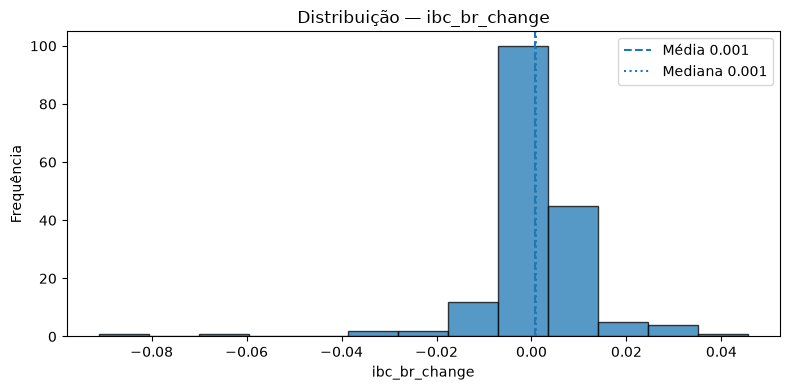

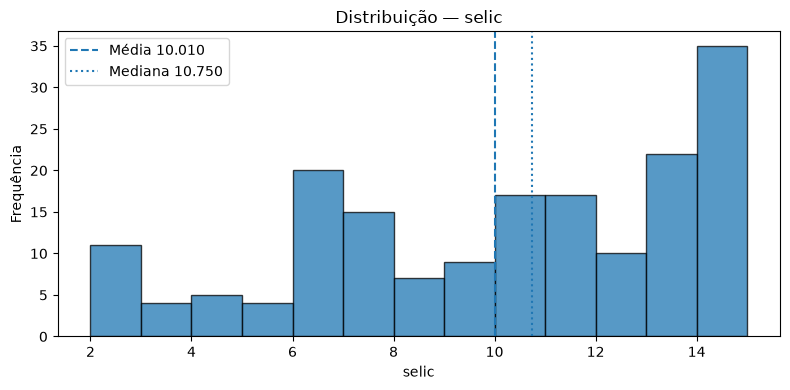

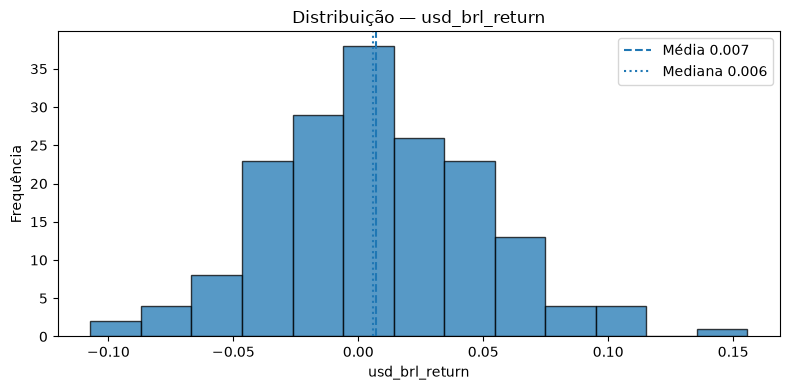

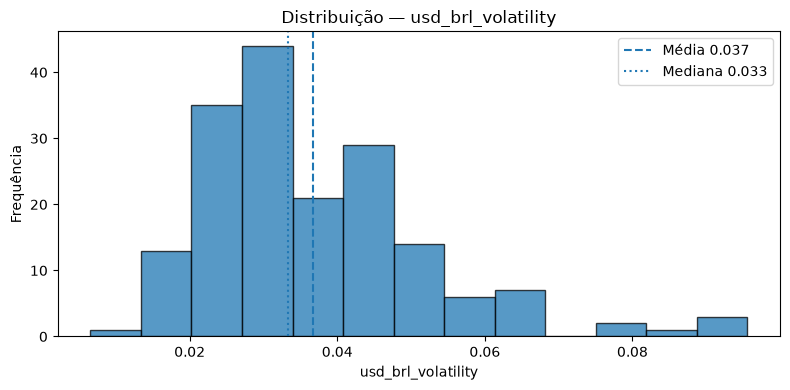

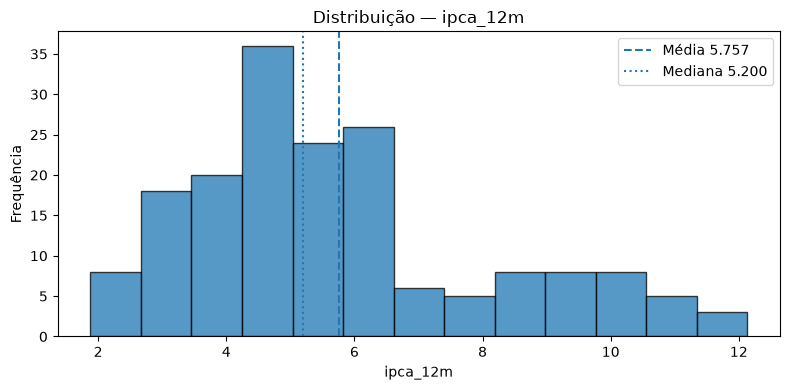

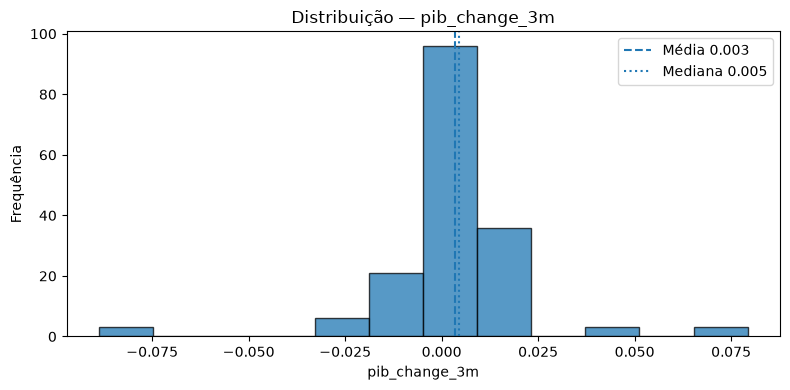

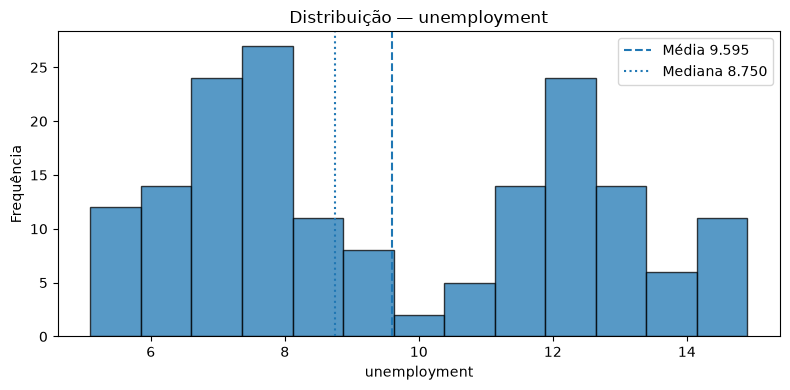

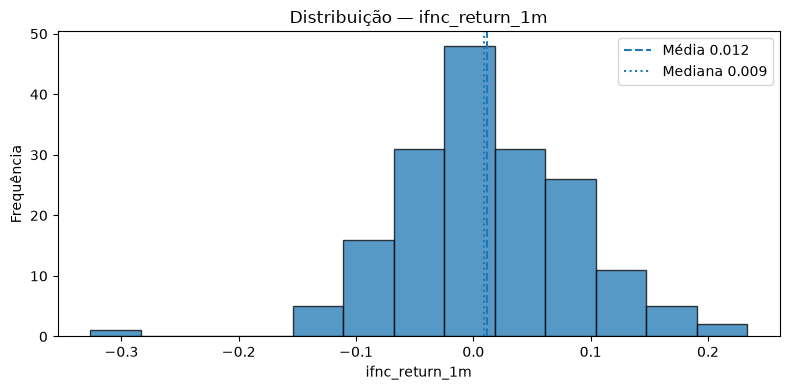

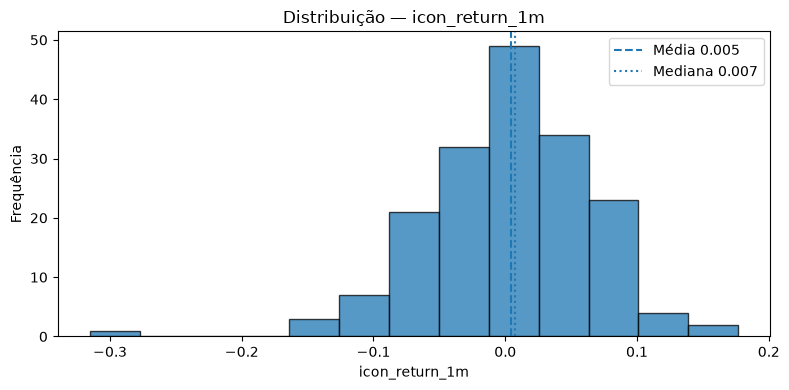

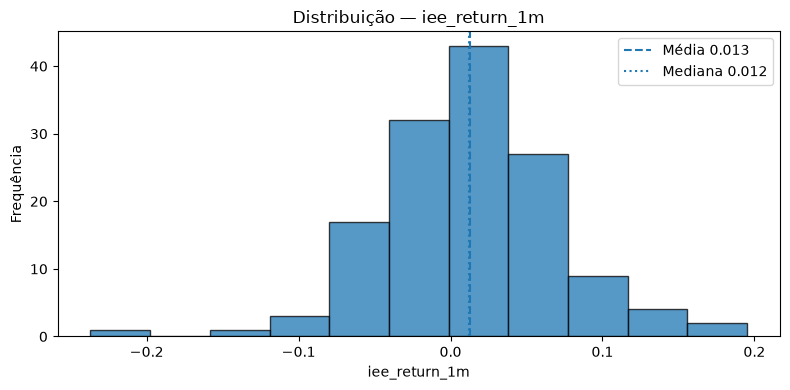

In [11]:
dist_cols = [c for c in [
    "ibc_br_change", "selic", "usd_brl_return", "usd_brl_volatility",
    "ipca_12m", "pib_change_3m", "unemployment",
    "ifnc_return_1m", "icon_return_1m", "iee_return_1m"
] if c in mvp_eda.columns]

for col in dist_cols:
    s = mvp_eda[col].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(s, bins=min(20, max(8, int(np.sqrt(len(s))))), edgecolor="black", alpha=.75)
    ax.axvline(s.mean(), linestyle="--", label=f"Média {s.mean():.3f}")
    ax.axvline(s.median(), linestyle=":", label=f"Mediana {s.median():.3f}")
    ax.set_title(f"Distribuição — {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")
    ax.legend()
    plt.tight_layout()
    plt.show()

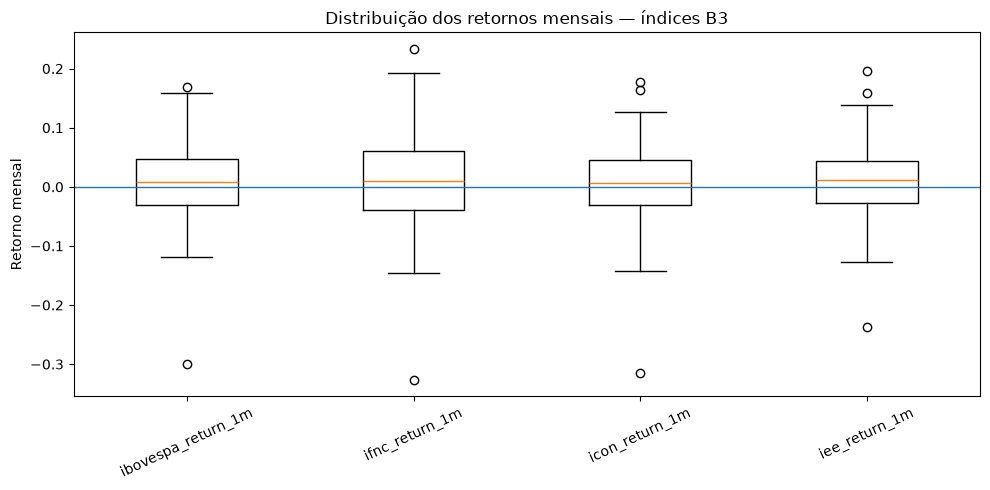

In [12]:
return_cols = [c for c in ["ibovespa_return_1m", "ifnc_return_1m", "icon_return_1m", "iee_return_1m"] if c in ref_eda.columns]
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([ref_eda[c].dropna() for c in return_cols], tick_labels=return_cols, showfliers=True)
ax.axhline(0, linewidth=1)
ax.set_title("Distribuição dos retornos mensais — índices B3")
ax.set_ylabel("Retorno mensal")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 8. Evolução temporal

Gráficos de linha ajudam a observar tendência, mudanças de nível e possíveis quebras. Variáveis com escalas muito diferentes são mostradas separadamente.

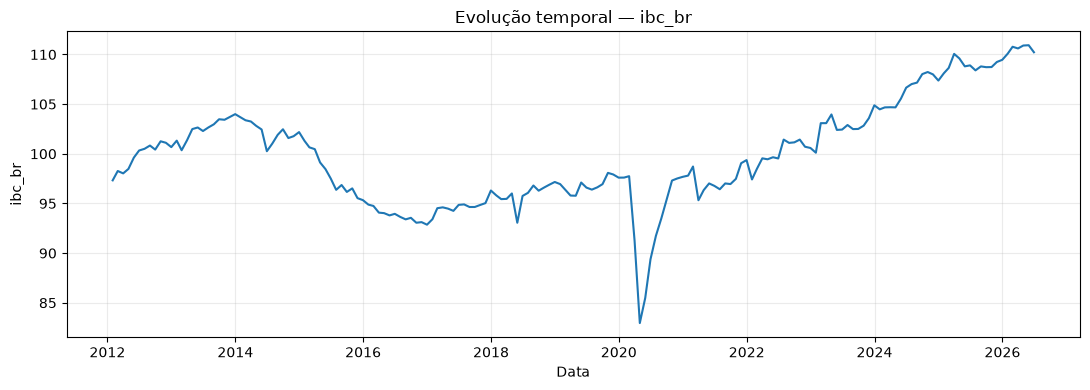

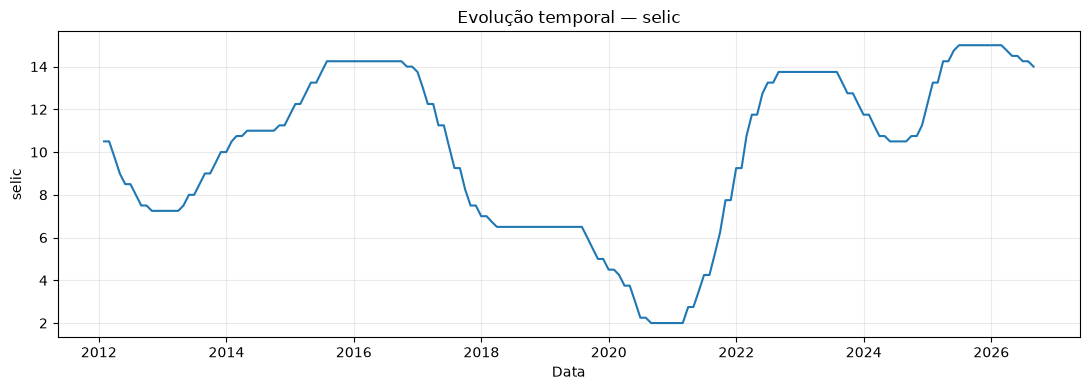

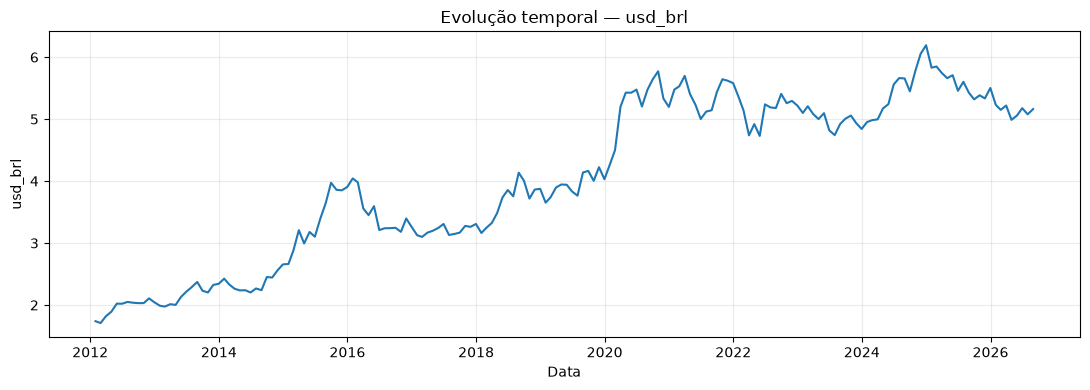

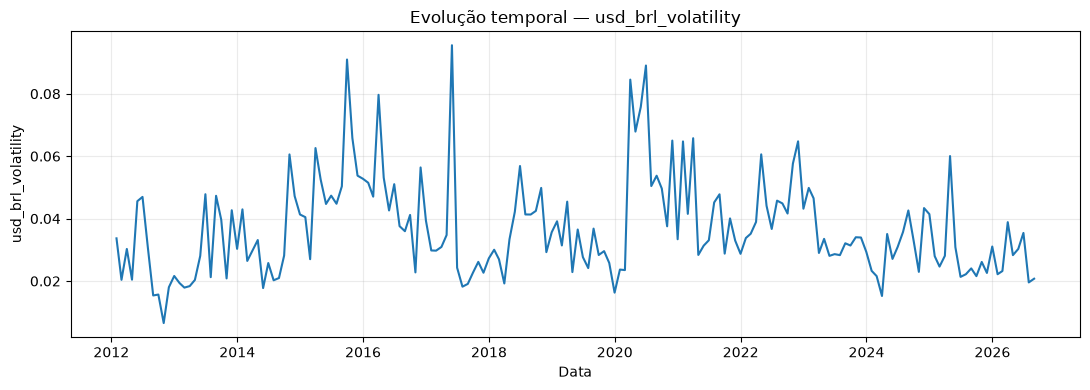

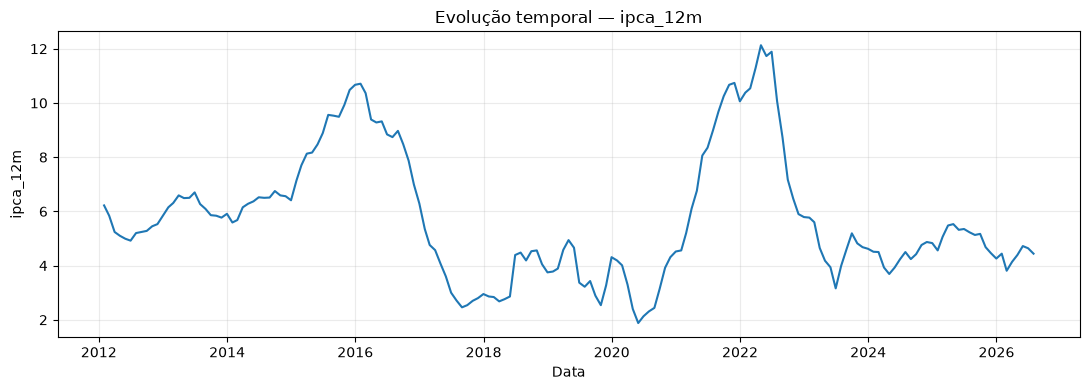

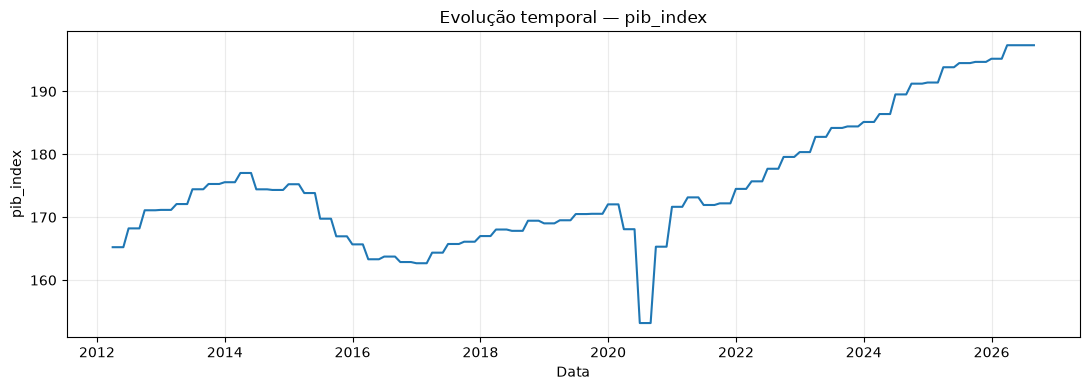

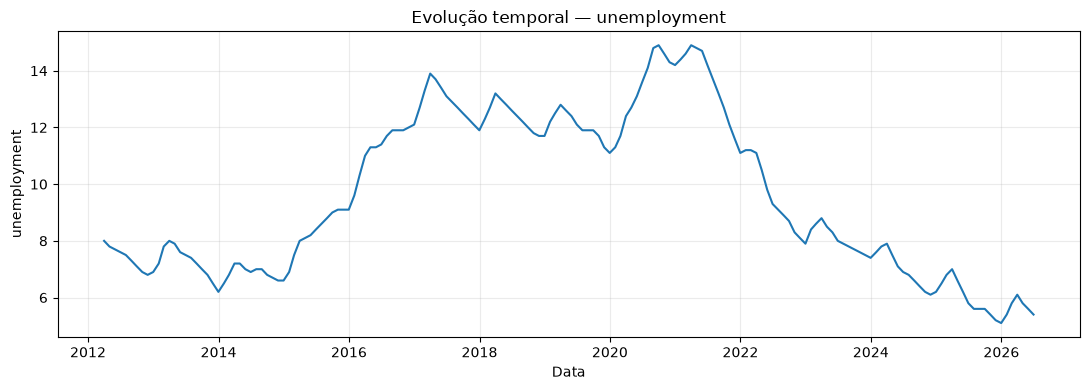

In [13]:
time_series_cols = [c for c in [
    "ibc_br", "selic", "usd_brl", "usd_brl_volatility", "ipca_12m", "pib_index", "unemployment"
] if c in ref_eda.columns]

for col in time_series_cols:
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(ref_eda["date"], ref_eda[col])
    ax.set_title(f"Evolução temporal — {col}")
    ax.set_xlabel("Data")
    ax.set_ylabel(col)
    ax.grid(alpha=.25)
    plt.tight_layout()
    plt.show()

### Índices normalizados para base 100

Os índices possuem níveis diferentes. Para comparar apenas a trajetória relativa, cada série é normalizada para começar em 100. Os valores originais não são alterados.

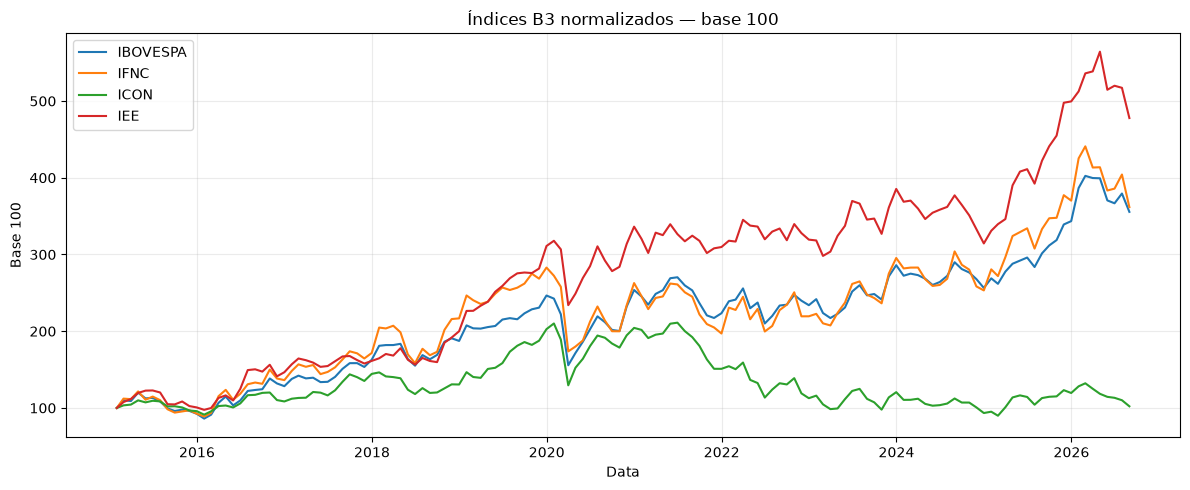

In [14]:
indices = [c for c in ["ibovespa", "ifnc", "icon", "iee"] if c in ref_eda.columns]
base_idx = ref_eda[["date"] + indices].dropna(subset=indices).copy()

normalized = base_idx[["date"]].copy()
for col in indices:
    normalized[col] = base_idx[col] / base_idx[col].iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 5))
for col in indices:
    ax.plot(normalized["date"], normalized[col], label=col.upper())
ax.set_title("Índices B3 normalizados — base 100")
ax.set_xlabel("Data")
ax.set_ylabel("Base 100")
ax.legend()
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

## 9. Retorno, risco e comportamento dos setores

Nesta etapa aprofundamos a análise dos índices de mercado. O objetivo não é identificar apenas qual setor apresentou maior retorno histórico, mas avaliar conjuntamente retorno, volatilidade e frequência de perdas.

Essa distinção é importante para o conceito de resiliência adotado neste projeto: um setor potencialmente resiliente não deve ser avaliado somente pela sua capacidade de gerar retorno, mas também pela magnitude e frequência das perdas.

In [15]:
# Métricas gerais de retorno e risco por índice.
sector_metrics = []
for index_name in ["ibovespa", "ifnc", "icon", "iee"]:
    ret_col = f"{index_name}_return_1m"
    vol_col = f"{index_name}_volatility_3m_ann"

    if ret_col not in ref_eda.columns:
        continue

    tmp_cols = ["date", ret_col]
    if vol_col in ref_eda.columns:
        tmp_cols.append(vol_col)

    tmp = ref_eda[tmp_cols].dropna(subset=[ret_col]).copy()

    sector_metrics.append({
        "indice": index_name.upper(),
        "observacoes": len(tmp),
        "retorno_medio": tmp[ret_col].mean(),
        "retorno_mediano": tmp[ret_col].median(),
        "volatilidade_retorno": tmp[ret_col].std(),
        "melhor_mes": tmp[ret_col].max(),
        "pior_mes": tmp[ret_col].min(),
        "meses_positivos_pct": (tmp[ret_col] > 0).mean(),
        "meses_negativos_pct": (tmp[ret_col] < 0).mean(),
        "volatilidade_media_3m": (
            tmp[vol_col].mean() if vol_col in tmp.columns else np.nan
        ),
    })

sector_metrics = pd.DataFrame(sector_metrics)

display(
    sector_metrics.style.format({
        "retorno_medio": "{:.2%}",
        "retorno_mediano": "{:.2%}",
        "volatilidade_retorno": "{:.2%}",
        "melhor_mes": "{:.2%}",
        "pior_mes": "{:.2%}",
        "meses_positivos_pct": "{:.1%}",
        "meses_negativos_pct": "{:.1%}",
        "volatilidade_media_3m": "{:.2%}",
    })
)

,indice,observacoes,retorno_medio,retorno_mediano,volatilidade_retorno,melhor_mes,pior_mes,meses_positivos_pct,meses_negativos_pct,volatilidade_media_3m
0,IBOVESPA,176,0.80%,0.76%,6.09%,16.97%,-29.90%,56.8%,43.2%,17.64%
1,IFNC,176,1.19%,0.91%,7.51%,23.34%,-32.63%,57.4%,42.6%,22.99%
2,ICON,176,0.46%,0.72%,6.28%,17.67%,-31.51%,56.2%,43.8%,17.57%
3,IEE,139,1.30%,1.23%,5.80%,19.52%,-23.70%,61.2%,38.8%,16.92%


## 10. Drawdown e velocidade de recuperação

O drawdown mede a distância entre o nível atual do índice e seu maior valor histórico observado até aquele momento.

Para a análise de resiliência, entretanto, a profundidade da perda não é suficiente. Também é relevante avaliar quanto tempo o índice leva para recuperar o nível anterior ao drawdown.

Nesta etapa analisamos:

- drawdown máximo;
- data do drawdown máximo;
- nível anterior à perda;
- tempo necessário para recuperação;
- percentual de períodos em drawdown.

A hipótese exploratória é que setores mais resilientes apresentem perdas menores e/ou recuperação mais rápida após períodos adversos.

,indice,pior_drawdown,data_pior_drawdown,data_pico_anterior,data_recuperacao,meses_para_recuperar,meses_em_drawdown
0,IBOVESPA,-38.60%,2016-01-31 00:00:00,2012-02-29 00:00:00,2017-02-28 00:00:00,60.000000,80.1%
1,IFNC,-38.60%,2020-03-31 00:00:00,2019-12-31 00:00:00,2023-12-31 00:00:00,48.000000,77.8%
2,ICON,-57.43%,2025-02-28 00:00:00,2021-06-30 00:00:00,NaT,nan,80.1%
3,IEE,-26.38%,2020-03-31 00:00:00,2020-01-31 00:00:00,2020-12-31 00:00:00,11.000000,65.7%


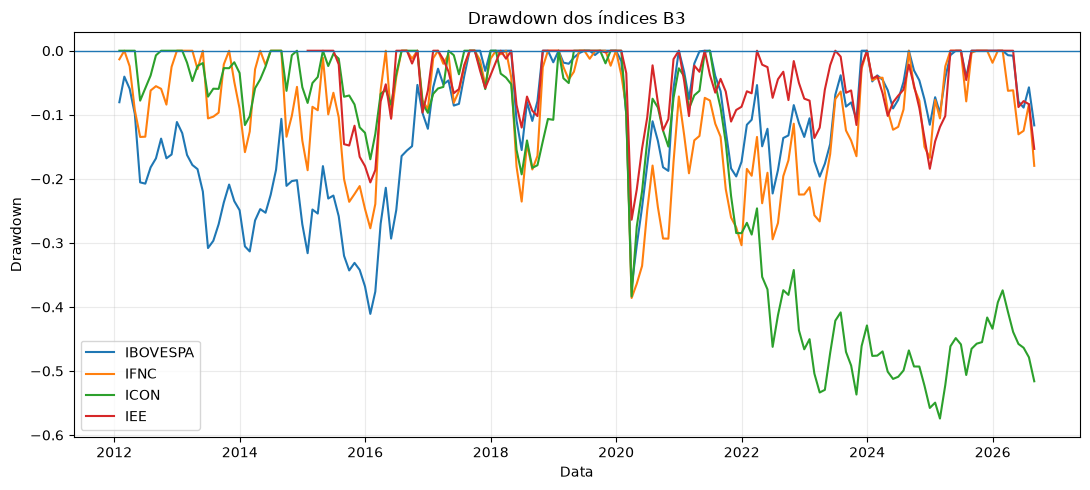

In [16]:
def recovery_metrics(df, index_name):
    value_col = index_name

    if value_col not in df.columns:
        return None

    tmp = df[["date", value_col]].dropna().copy()
    tmp = tmp.sort_values("date").reset_index(drop=True)

    # Máximo histórico até cada ponto.
    tmp["peak"] = tmp[value_col].cummax()

    # Drawdown.
    tmp["drawdown_calc"] = tmp[value_col] / tmp["peak"] - 1

    # Pior drawdown.
    worst_idx = tmp["drawdown_calc"].idxmin()
    worst_row = tmp.loc[worst_idx]

    peak_before = worst_row["peak"]
    peak_date = tmp.loc[
        tmp.loc[:worst_idx, value_col].idxmax(), "date"
    ]

    # Procura o primeiro momento posterior em que o índice
    # retorna ao nível do pico anterior.
    recovery = tmp.loc[
        (tmp.index > worst_idx) &
        (tmp[value_col] >= peak_before)
    ]

    if recovery.empty:
        recovery_date = pd.NaT
        recovery_months = np.nan
    else:
        recovery_date = recovery.iloc[0]["date"]
        recovery_months = (
            (recovery_date.year - peak_date.year) * 12
            + recovery_date.month - peak_date.month
        )

    return {
        "indice": index_name.upper(),
        "pior_drawdown": worst_row["drawdown_calc"],
        "data_pior_drawdown": worst_row["date"],
        "data_pico_anterior": peak_date,
        "data_recuperacao": recovery_date,
        "meses_para_recuperar": recovery_months,
        "meses_em_drawdown": (tmp["drawdown_calc"] < 0).mean(),
    }


recovery_rows = []

for index_name in ["ibovespa", "ifnc", "icon", "iee"]:
    result = recovery_metrics(ref_eda, index_name)
    if result:
        recovery_rows.append(result)

recovery_table = pd.DataFrame(recovery_rows)

display(
    recovery_table.style.format({
        "pior_drawdown": "{:.2%}",
        "meses_em_drawdown": "{:.1%}",
    })
)


fig, ax = plt.subplots(figsize=(11, 5))

for index_name in ["ibovespa", "ifnc", "icon", "iee"]:
    dd_col = f"{index_name}_drawdown"

    if dd_col in ref_eda.columns:
        ax.plot(
            ref_eda["date"],
            ref_eda[dd_col],
            label=index_name.upper()
        )

ax.axhline(0, linewidth=1)
ax.set_title("Drawdown dos índices B3")
ax.set_xlabel("Data")
ax.set_ylabel("Drawdown")
ax.legend()
ax.grid(alpha=.25)

plt.tight_layout()
plt.show()

## 11. Identificação exploratória de períodos de stress

Antes da construção do modelo de classificação, é importante investigar se os próprios dados apresentam períodos caracterizados simultaneamente por deterioração econômica, aumento de inflação, pressão cambial, aumento do desemprego e/ou maior volatilidade.

Nesta etapa será construído um indicador exploratório denominado **Stress Score**.

O indicador não representa ainda o target definitivo do modelo. Seu objetivo é:

1. identificar períodos potencialmente estressados;
2. comparar esses períodos com eventos econômicos conhecidos;
3. gerar hipóteses para a definição posterior do target `stress`.

As variáveis serão transformadas em scores padronizados para permitir a comparação entre indicadores com escalas diferentes.

In [17]:
# Variáveis e direção esperada de estresse.
# +1 significa que valores altos representam maior estresse.
# -1 significa que valores baixos representam maior estresse.

stress_components = {
    "ibc_br_change": -1,
    "selic_change": 1,
    "usd_brl_return": 1,
    "usd_brl_volatility": 1,
    "ipca_12m": 1,
    "unemployment_change": 1,
    "pib_change_3m": -1,
}

stress_data = mvp_eda[["date"]].copy()

for col, direction in stress_components.items():
    if col not in mvp_eda.columns:
        continue

    series = mvp_eda[col]

    # Padronização.
    z = (series - series.mean()) / series.std()

    # Ajusta direção econômica do indicador.
    stress_data[f"{col}_stress_z"] = z * direction

stress_score_cols = [
    c for c in stress_data.columns
    if c.endswith("_stress_z")
]

# Média dos componentes disponíveis.
stress_data["stress_score"] = stress_data[stress_score_cols].mean(axis=1)

display(
    stress_data[
        ["date", "stress_score"] + stress_score_cols
    ].sort_values("stress_score", ascending=False).head(20)
)

,date,stress_score,ibc_br_change_stress_z,selic_change_stress_z,usd_brl_return_stress_z,usd_brl_volatility_stress_z,ipca_12m_stress_z,unemployment_change_stress_z,pib_change_3m_stress_z
44,2015-09-30,1.4424,0.9794,-0.0465,1.9501,3.4851,1.5962,0.7150,1.4174
101,2020-06-30,1.4216,7.2020,-1.7905,0.0485,3.3617,-1.6403,1.3795,1.3904
38,2015-03-31,1.2614,0.7384,1.1162,2.5453,1.6624,0.8220,2.0440,-0.0985
42,2015-07-31,0.9890,0.5947,1.1162,2.0559,0.5162,1.3254,0.7150,0.5994
43,2015-08-31,0.8804,0.8158,-0.0465,1.5949,0.8752,1.6089,0.7150,0.5994
98,2020-03-31,0.8271,0.0576,-1.2092,3.5167,3.0713,-0.7391,1.3795,-0.2874
48,2016-01-31,0.8014,0.8612,-0.0465,0.6686,0.9485,2.0785,0.0505,1.0488
50,2016-03-31,0.7682,0.4314,-0.0465,-2.6721,2.7586,1.9474,2.3762,0.5824
104,2020-09-30,0.7397,-2.0096,-0.0465,0.5648,0.8294,-1.4034,2.3762,4.8672
49,2016-02-29,0.7374,0.2284,-0.0465,-0.5387,0.6625,2.0954,1.7117,1.0488


In [18]:
# Classificação exploratória baseada nos percentis do Stress Score.
# Não utilizar esta classificação como target definitivo ainda.

q75 = stress_data["stress_score"].quantile(.75)
q90 = stress_data["stress_score"].quantile(.90)

stress_data["stress_level"] = np.select(
    [
        stress_data["stress_score"] >= q90,
        stress_data["stress_score"] >= q75,
    ],
    [
        "Stress elevado",
        "Atenção",
    ],
    default="Normal"
)

display(
    stress_data[
        ["date", "stress_score", "stress_level"]
    ].sort_values("stress_score", ascending=False).head(30)
)

,date,stress_score,stress_level
44,2015-09-30,1.4424,Stress elevado
101,2020-06-30,1.4216,Stress elevado
38,2015-03-31,1.2614,Stress elevado
42,2015-07-31,0.9890,Stress elevado
43,2015-08-31,0.8804,Stress elevado
98,2020-03-31,0.8271,Stress elevado
48,2016-01-31,0.8014,Stress elevado
50,2016-03-31,0.7682,Stress elevado
104,2020-09-30,0.7397,Stress elevado
49,2016-02-29,0.7374,Stress elevado


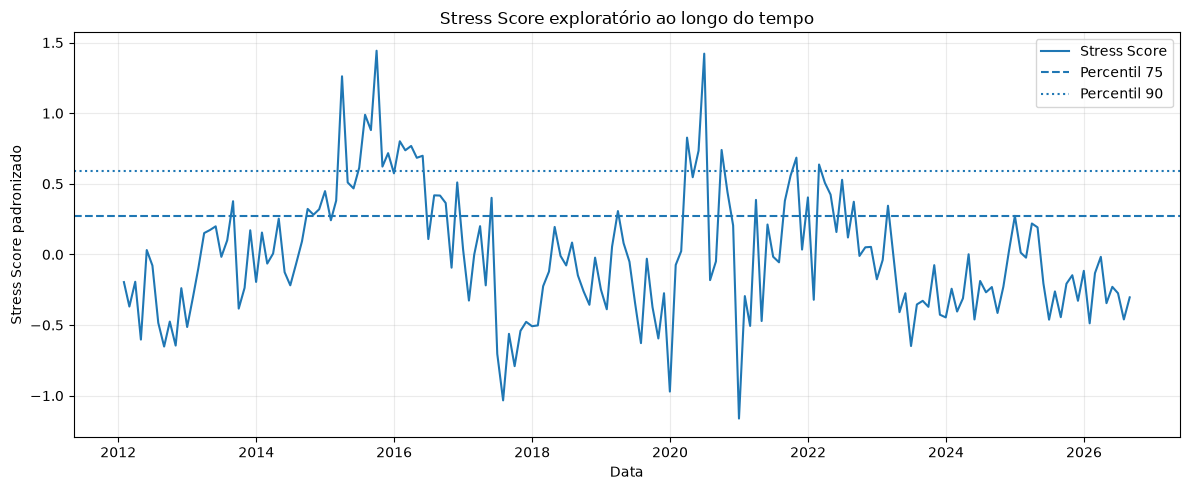

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    stress_data["date"],
    stress_data["stress_score"],
    label="Stress Score"
)

ax.axhline(q75, linestyle="--", label="Percentil 75")
ax.axhline(q90, linestyle=":", label="Percentil 90")

ax.set_title("Stress Score exploratório ao longo do tempo")
ax.set_xlabel("Data")
ax.set_ylabel("Stress Score padronizado")
ax.legend()
ax.grid(alpha=.25)

plt.tight_layout()
plt.show()

## 12. Validação exploratória dos períodos de stress

O Stress Score permite identificar períodos sem depender exclusivamente de uma classificação manual.

Nesta etapa comparamos:

- períodos históricos previamente definidos;
- meses classificados pelo Stress Score;
- intensidade média do estresse em cada período.

A finalidade é verificar se o indicador apresenta coerência econômica e se os períodos historicamente reconhecidos como adversos aparecem entre os valores mais elevados.

Essa comparação é exploratória e não representa validação causal.

In [20]:
periods = {
    "Recessão 2015-2016": ("2015-01-01", "2016-12-31"),
    "Pré-pandemia 2018-2019": ("2018-01-01", "2019-12-31"),
    "Pandemia 2020": ("2020-01-01", "2020-12-31"),
    "Inflação/juros 2021-2022": ("2021-01-01", "2022-12-31"),
    "2023 em diante": ("2023-01-01", str(last_closed_month.date())),
}

def period_metrics(df, period_name, start, end, index_name):
    ret_col = f"{index_name}_return_1m"
    dd_col = f"{index_name}_drawdown"
    tmp = df.loc[df["date"].between(pd.Timestamp(start), pd.Timestamp(end)), ["date", ret_col, dd_col]].dropna(subset=[ret_col])
    if tmp.empty:
        return None
    compounded = (1 + tmp[ret_col]).prod() - 1
    return {
        "periodo": period_name,
        "indice": index_name.upper(),
        "meses": len(tmp),
        "retorno_acumulado": compounded,
        "retorno_medio_mensal": tmp[ret_col].mean(),
        "volatilidade_mensal": tmp[ret_col].std(),
        "pior_drawdown_observado": tmp[dd_col].min(),
        "melhor_mes": tmp[ret_col].max(),
        "pior_mes": tmp[ret_col].min(),
    }

rows = []
for pname, (start, end) in periods.items():
    for idx_name in ["ibovespa", "ifnc", "icon", "iee"]:
        r = period_metrics(ref_eda, pname, start, end, idx_name)
        if r:
            rows.append(r)
period_table = pd.DataFrame(rows)
display(period_table)

,periodo,indice,meses,retorno_acumulado,retorno_medio_mensal,volatilidade_mensal,pior_drawdown_observado,melhor_mes,pior_mes
0,Recessão 2015-2016,IBOVESPA,24,0.2044,0.0103,0.0729,-0.4109,0.1697,-0.1009
1,Recessão 2015-2016,IFNC,24,0.2893,0.0140,0.0849,-0.2772,0.2334,-0.1077
2,Recessão 2015-2016,ICON,24,0.0566,0.0032,0.0426,-0.1695,0.1008,-0.0820
3,Recessão 2015-2016,IEE,23,0.4657,0.0193,0.0741,-0.2056,0.1952,-0.1272
4,Pré-pandemia 2018-2019,IBOVESPA,24,0.5136,0.0187,0.0513,-0.1551,0.1114,-0.1087
5,Pré-pandemia 2018-2019,IFNC,24,0.6483,0.0237,0.0753,-0.2355,0.1928,-0.1453
6,Pré-pandemia 2018-2019,ICON,24,0.4039,0.0156,0.0532,-0.1930,0.1231,-0.1079
7,Pré-pandemia 2018-2019,IEE,24,0.9286,0.0290,0.0518,-0.1200,0.1587,-0.0845
8,Pandemia 2020,IBOVESPA,12,0.0292,0.0101,0.1226,-0.3686,0.1590,-0.2990
9,Pandemia 2020,IFNC,12,-0.0714,0.0030,0.1328,-0.3860,0.1693,-0.3263


In [21]:
# Reutiliza os períodos históricos já definidos no notebook.
stress_period_rows = []

for period_name, (start, end) in periods.items():
    tmp = stress_data[
        stress_data["date"].between(
            pd.Timestamp(start),
            pd.Timestamp(end)
        )
    ].copy()

    if tmp.empty:
        continue

    stress_period_rows.append({
        "periodo": period_name,
        "meses": len(tmp),
        "stress_medio": tmp["stress_score"].mean(),
        "stress_maximo": tmp["stress_score"].max(),
        "pct_stress_elevado": (
            tmp["stress_level"].eq("Stress elevado").mean()
        ),
        "pct_atencao_ou_stress": (
            tmp["stress_level"].isin(
                ["Atenção", "Stress elevado"]
            ).mean()
        ),
    })

stress_period_table = pd.DataFrame(stress_period_rows)

display(
    stress_period_table.style.format({
        "stress_medio": "{:.2f}",
        "stress_maximo": "{:.2f}",
        "pct_stress_elevado": "{:.1%}",
        "pct_atencao_ou_stress": "{:.1%}",
    })
)

,periodo,meses,stress_medio,stress_maximo,pct_stress_elevado,pct_atencao_ou_stress
0,Recessão 2015-2016,24,0.59,1.44,50.0%,83.3%
1,Pré-pandemia 2018-2019,24,-0.20,0.31,0.0%,4.2%
2,Pandemia 2020,12,0.29,1.42,33.3%,50.0%
3,Inflação/juros 2021-2022,24,0.15,0.69,8.3%,41.7%
4,2023 em diante,44,-0.22,0.34,0.0%,2.3%


In [22]:
# Meses com maior Stress Score.
top_stress_months = (
    stress_data[
        ["date", "stress_score", "stress_level"]
    ]
    .sort_values("stress_score", ascending=False)
    .head(15)
)

display(top_stress_months)

,date,stress_score,stress_level
44,2015-09-30,1.4424,Stress elevado
101,2020-06-30,1.4216,Stress elevado
38,2015-03-31,1.2614,Stress elevado
42,2015-07-31,0.9890,Stress elevado
43,2015-08-31,0.8804,Stress elevado
98,2020-03-31,0.8271,Stress elevado
48,2016-01-31,0.8014,Stress elevado
50,2016-03-31,0.7682,Stress elevado
104,2020-09-30,0.7397,Stress elevado
49,2016-02-29,0.7374,Stress elevado


## 13. Stress × Normal: comportamento dos setores

A principal pergunta desta análise é:

> **Os setores apresentam comportamentos diferentes quando o ambiente macroeconômico está sob maior estresse?**

Para responder exploratoriamente, os meses serão divididos em:

- **Normal**: Stress Score abaixo do percentil 75;
- **Stress**: Stress Score igual ou acima do percentil 75.

Para cada índice serão comparados:

- retorno médio;
- retorno acumulado;
- volatilidade;
- frequência de meses negativos;
- pior retorno mensal.

A classificação será utilizada apenas para análise exploratória. O target definitivo do modelo será definido posteriormente.

In [23]:
# Junta o regime exploratório com os dados de mercado.
analysis_regime = ref_eda.merge(
    stress_data[["date", "stress_score", "stress_level"]],
    on="date",
    how="left"
)

analysis_regime["regime_eda"] = np.where(
    analysis_regime["stress_score"] >= q75,
    "Stress",
    "Normal"
)

stress_normal_rows = []

for index_name in ["ibovespa", "ifnc", "icon", "iee"]:
    ret_col = f"{index_name}_return_1m"

    if ret_col not in analysis_regime.columns:
        continue

    for regime in ["Normal", "Stress"]:
        tmp = analysis_regime[
            analysis_regime["regime_eda"] == regime
        ][["date", ret_col]].dropna()

        if tmp.empty:
            continue

        stress_normal_rows.append({
            "indice": index_name.upper(),
            "regime": regime,
            "meses": len(tmp),
            "retorno_medio": tmp[ret_col].mean(),
            "retorno_acumulado": (1 + tmp[ret_col]).prod() - 1,
            "volatilidade": tmp[ret_col].std(),
            "meses_negativos_pct": (tmp[ret_col] < 0).mean(),
            "pior_mes": tmp[ret_col].min(),
        })

stress_normal = pd.DataFrame(stress_normal_rows)

display(
    stress_normal.style.format({
        "retorno_medio": "{:.2%}",
        "retorno_acumulado": "{:.2%}",
        "volatilidade": "{:.2%}",
        "meses_negativos_pct": "{:.1%}",
        "pior_mes": "{:.2%}",
    })
)

,indice,regime,meses,retorno_medio,retorno_acumulado,volatilidade,meses_negativos_pct,pior_mes
0,IBOVESPA,Normal,132,1.33%,386.62%,5.10%,40.2%,-11.86%
1,IBOVESPA,Stress,44,-0.79%,-39.61%,8.25%,52.3%,-29.90%
2,IFNC,Normal,132,1.96%,886.32%,6.67%,37.9%,-14.53%
3,IFNC,Stress,44,-1.14%,-50.60%,9.30%,56.8%,-32.63%
4,ICON,Normal,132,0.97%,192.92%,5.59%,39.4%,-14.29%
5,ICON,Stress,44,-1.07%,-46.35%,7.88%,56.8%,-31.51%
6,IEE,Normal,100,1.66%,357.33%,5.07%,36.0%,-8.79%
7,IEE,Stress,39,0.38%,4.48%,7.36%,46.2%,-23.70%


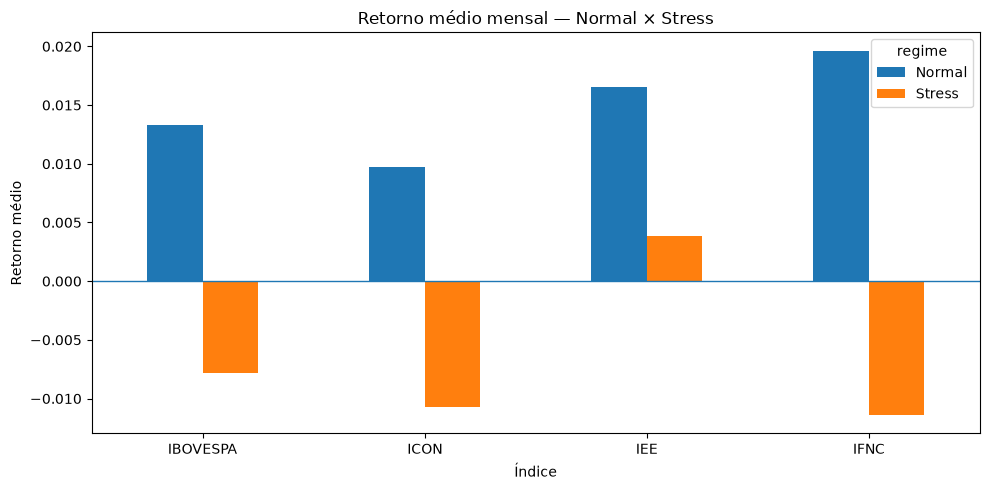

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

pivot = stress_normal.pivot(
    index="indice",
    columns="regime",
    values="retorno_medio"
)

pivot.plot(
    kind="bar",
    ax=ax
)

ax.axhline(0, linewidth=1)
ax.set_title("Retorno médio mensal — Normal × Stress")
ax.set_xlabel("Índice")
ax.set_ylabel("Retorno médio")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 14. Análise de defasagens entre indicadores macroeconômicos e setores

Esta análise verifica se mudanças macroeconômicas aparecem associadas aos retornos dos índices no mesmo mês ou alguns meses depois.

São avaliados lags de 0, 1, 3 e 6 meses. Por exemplo, `lag_meses = 3` compara o indicador macroeconômico observado três meses antes com o retorno setorial do mês atual.

Para esta análise exploratória são usados os valores pelo **mês de referência econômica**. Isso é diferente dos lags de disponibilidade aplicados no `dataset_mvp.csv` para reduzir *look-ahead bias* na futura modelagem.

O objetivo não é provar causalidade nem selecionar automaticamente um lag para o modelo. A análise serve para levantar hipóteses sobre relações que podem ocorrer com atraso.


In [25]:
# ============================================================
# 14. ANÁLISE DE DEFASAGENS MACROECONÔMICAS
# ============================================================
# Objetivo: verificar se mudanças macroeconômicas observadas em t-lag
# apresentam associação com o retorno setorial em t.
# Ex.: lag=3 -> correlaciona o indicador macro de 3 meses atrás
# com o retorno do setor no mês atual.
#
# Para esta EDA usamos o dataset de referência (mês econômico), e não
# o dataset MVP já defasado para modelagem. Isso evita somar dois tipos
# diferentes de lag e deixa a interpretação econômica mais clara.

lag_base = ref_eda.copy()

# Algumas variações são criadas apenas no dataset MVP pelo preprocessamento.
# Para a análise histórica de defasagem, recalculamos essas transformações
# diretamente sobre o dataset de referência, quando necessário.
if "ibc_br_change" not in lag_base.columns and "ibc_br" in lag_base.columns:
    lag_base["ibc_br_change"] = lag_base["ibc_br"].pct_change(fill_method=None)

if "selic_change" not in lag_base.columns and "selic" in lag_base.columns:
    lag_base["selic_change"] = lag_base["selic"].diff()

if "usd_brl_return" not in lag_base.columns and "usd_brl" in lag_base.columns:
    lag_base["usd_brl_return"] = lag_base["usd_brl"].pct_change(fill_method=None)

if "unemployment_change" not in lag_base.columns and "unemployment" in lag_base.columns:
    lag_base["unemployment_change"] = lag_base["unemployment"].diff()

if "pib_change_3m" not in lag_base.columns and "pib_index" in lag_base.columns:
    lag_base["pib_change_3m"] = lag_base["pib_index"].pct_change(3, fill_method=None)

macro_lag_features = [
    "ibc_br_change",
    "selic_change",
    "usd_brl_return",
    "usd_brl_volatility",
    "ipca_12m",
    "unemployment_change",
    "pib_change_3m",
]

# Os nomes reais gerados no preprocessamento possuem o sufixo _return_1m.
sector_lag_features = [
    "ibovespa_return_1m",
    "ifnc_return_1m",
    "icon_return_1m",
    "iee_return_1m",
]

available_macro = [c for c in macro_lag_features if c in lag_base.columns]
available_sectors = [c for c in sector_lag_features if c in lag_base.columns]

missing_macro = [c for c in macro_lag_features if c not in lag_base.columns]
missing_sectors = [c for c in sector_lag_features if c not in lag_base.columns]

print("Variáveis macro disponíveis:")
print(available_macro)
if missing_macro:
    print("Variáveis macro não disponíveis:", missing_macro)

print("\nÍndices/setores disponíveis:")
print(available_sectors)
if missing_sectors:
    print("Índices/setores não disponíveis:", missing_sectors)

lags = [0, 1, 3, 6]
lag_rows = []

for macro in available_macro:
    for sector in available_sectors:
        for lag in lags:
            temp = lag_base[[macro, sector]].copy()

            # shift(lag): o valor macro de t-lag é alinhado ao retorno em t.
            if lag > 0:
                temp[macro] = temp[macro].shift(lag)

            temp = temp.dropna()
            if len(temp) < 10:
                continue

            pearson = temp[macro].corr(temp[sector], method="pearson")
            spearman = temp[macro].corr(temp[sector], method="spearman")

            lag_rows.append({
                "macro": macro,
                "setor": sector,
                "lag_meses": lag,
                "observacoes": len(temp),
                "pearson": pearson,
                "spearman": spearman,
                "abs_pearson": abs(pearson),
                "abs_spearman": abs(spearman),
            })

lag_results = pd.DataFrame(lag_rows)

if lag_results.empty:
    print("Nenhum resultado de defasagem foi gerado.")
else:
    display(
        lag_results
        .sort_values(["setor", "abs_pearson"], ascending=[True, False])
        .head(30)
    )


Variáveis macro disponíveis:
['ibc_br_change', 'selic_change', 'usd_brl_return', 'usd_brl_volatility', 'ipca_12m', 'unemployment_change', 'pib_change_3m']

Índices/setores disponíveis:
['ibovespa_return_1m', 'ifnc_return_1m', 'icon_return_1m', 'iee_return_1m']


,macro,setor,lag_meses,observacoes,pearson,spearman,abs_pearson,abs_spearman
32,usd_brl_return,ibovespa_return_1m,0,175,-0.6579,-0.6342,0.6579,0.6342
35,usd_brl_return,ibovespa_return_1m,6,169,-0.1348,-0.1775,0.1348,0.1775
49,usd_brl_volatility,ibovespa_return_1m,1,175,0.1310,0.0576,0.1310,0.0576
19,selic_change,ibovespa_return_1m,6,169,-0.1286,-0.0701,0.1286,0.0701
34,usd_brl_return,ibovespa_return_1m,3,172,0.1249,0.1125,0.1249,0.1125
0,ibc_br_change,ibovespa_return_1m,0,173,0.1224,0.0603,0.1224,0.0603
50,usd_brl_volatility,ibovespa_return_1m,3,173,0.1105,0.0737,0.1105,0.0737
51,usd_brl_volatility,ibovespa_return_1m,6,170,0.1097,0.0323,0.1097,0.0323
64,ipca_12m,ibovespa_return_1m,0,175,-0.1042,-0.1244,0.1042,0.1244
48,usd_brl_volatility,ibovespa_return_1m,0,176,-0.0947,-0.1179,0.0947,0.1179


### 14.1 Melhor defasagem por relação

Para cada combinação entre indicador macroeconômico e setor, selecionamos a defasagem que apresentou a maior correlação absoluta.

O objetivo não é afirmar que essa é uma relação causal, mas identificar possíveis janelas temporais relevantes para a modelagem.


In [26]:
if lag_results.empty:
    best_lags = pd.DataFrame()
    print("Não há resultados suficientes para selecionar a melhor defasagem.")
else:
    best_lags = (
        lag_results
        .sort_values(
            ["macro", "setor", "abs_pearson"],
            ascending=[True, True, False]
        )
        .drop_duplicates(subset=["macro", "setor"])
        .sort_values("abs_pearson", ascending=False)
    )
    display(best_lags)


,macro,setor,lag_meses,observacoes,pearson,spearman,abs_pearson,abs_spearman
32,usd_brl_return,ibovespa_return_1m,0,175,-0.6579,-0.6342,0.6579,0.6342
36,usd_brl_return,ifnc_return_1m,0,175,-0.6551,-0.6386,0.6551,0.6386
44,usd_brl_return,iee_return_1m,0,139,-0.5692,-0.5249,0.5692,0.5249
40,usd_brl_return,icon_return_1m,0,175,-0.4722,-0.4577,0.4722,0.4577
27,selic_change,icon_return_1m,6,169,-0.1890,-0.1257,0.1890,0.1257
72,ipca_12m,icon_return_1m,0,175,-0.1566,-0.1324,0.1566,0.1324
4,ibc_br_change,ifnc_return_1m,0,173,0.1473,0.0549,0.1473,0.0549
12,ibc_br_change,iee_return_1m,0,137,0.1379,0.0854,0.1379,0.0854
49,usd_brl_volatility,ibovespa_return_1m,1,175,0.1310,0.0576,0.1310,0.0576
19,selic_change,ibovespa_return_1m,6,169,-0.1286,-0.0701,0.1286,0.0701


### Interpretação

As relações encontradas nesta etapa devem ser tratadas como hipóteses para o modelo.

Uma correlação mais forte em determinada defasagem pode indicar que o mercado incorpora mudanças macroeconômicas de maneira gradual, ou simplesmente refletir tendências comuns entre as séries.

Essas relações deverão ser posteriormente avaliadas respeitando a disponibilidade temporal das informações, evitando look-ahead bias.


## 15. Correlação entre indicadores macroeconômicos e setores por regime

A correlação entre variáveis pode mudar significativamente durante períodos de estresse.

Por isso, nesta etapa comparamos as relações macroeconômicas e setoriais em três perspectivas:

- Todos os períodos;
- Períodos classificados como Normal;
- Períodos classificados como Stress.

O objetivo é verificar se determinados setores apresentam comportamento diferente justamente nos momentos de maior pressão econômica.


In [27]:
# ============================================================
# 15. CORRELAÇÃO POR REGIME
# ============================================================
# Usa a mesma base de referência enriquecida da seção 14 para manter
# consistência nos nomes e nas transformações macroeconômicas.

analysis_regime_corr = lag_base.copy()
analysis_regime_corr = analysis_regime_corr.merge(
    stress_data[["date", "stress_score"]],
    on="date",
    how="left"
)

q75_corr = analysis_regime_corr["stress_score"].quantile(0.75)
analysis_regime_corr["regime_eda"] = np.where(
    analysis_regime_corr["stress_score"] >= q75_corr,
    "Stress",
    "Normal"
)

regime_rows = []

for macro in available_macro:
    for sector in available_sectors:
        for regime in ["Todos", "Normal", "Stress"]:
            if regime == "Todos":
                temp = analysis_regime_corr[[macro, sector]].dropna()
            else:
                temp = analysis_regime_corr.loc[
                    analysis_regime_corr["regime_eda"] == regime,
                    [macro, sector]
                ].dropna()

            if len(temp) < 10:
                continue

            regime_rows.append({
                "macro": macro,
                "setor": sector,
                "regime": regime,
                "observacoes": len(temp),
                "pearson": temp[macro].corr(temp[sector], method="pearson"),
                "spearman": temp[macro].corr(temp[sector], method="spearman"),
            })

regime_correlations = pd.DataFrame(regime_rows)

if regime_correlations.empty:
    print("Não há observações suficientes para a correlação por regime.")
else:
    display(regime_correlations)


,macro,setor,regime,observacoes,pearson,spearman
0,ibc_br_change,ibovespa_return_1m,Todos,173,0.1224,0.0603
1,ibc_br_change,ibovespa_return_1m,Normal,129,0.1030,0.1077
2,ibc_br_change,ibovespa_return_1m,Stress,44,0.1096,-0.1360
3,ibc_br_change,ifnc_return_1m,Todos,173,0.1473,0.0549
4,ibc_br_change,ifnc_return_1m,Normal,129,0.0738,0.1110
...,...,...,...,...,...,...
79,pib_change_3m,icon_return_1m,Normal,127,0.0353,0.1196
80,pib_change_3m,icon_return_1m,Stress,44,-0.1746,-0.1817
81,pib_change_3m,iee_return_1m,Todos,139,0.0359,0.0147
82,pib_change_3m,iee_return_1m,Normal,100,0.0527,0.0091


### 15.1 Exemplo: relação entre Selic e setores

A seguir avaliamos visualmente se a relação entre variações da Selic e retornos setoriais se modifica entre os regimes Normal e Stress.


regime,Normal,Stress,Todos
setor,,,
ibovespa_return_1m,-0.0309,0.0280,-0.0489
icon_return_1m,-0.0663,-0.0490,-0.0976
iee_return_1m,-0.0505,0.0597,-0.0327
ifnc_return_1m,0.0201,-0.0045,-0.0426


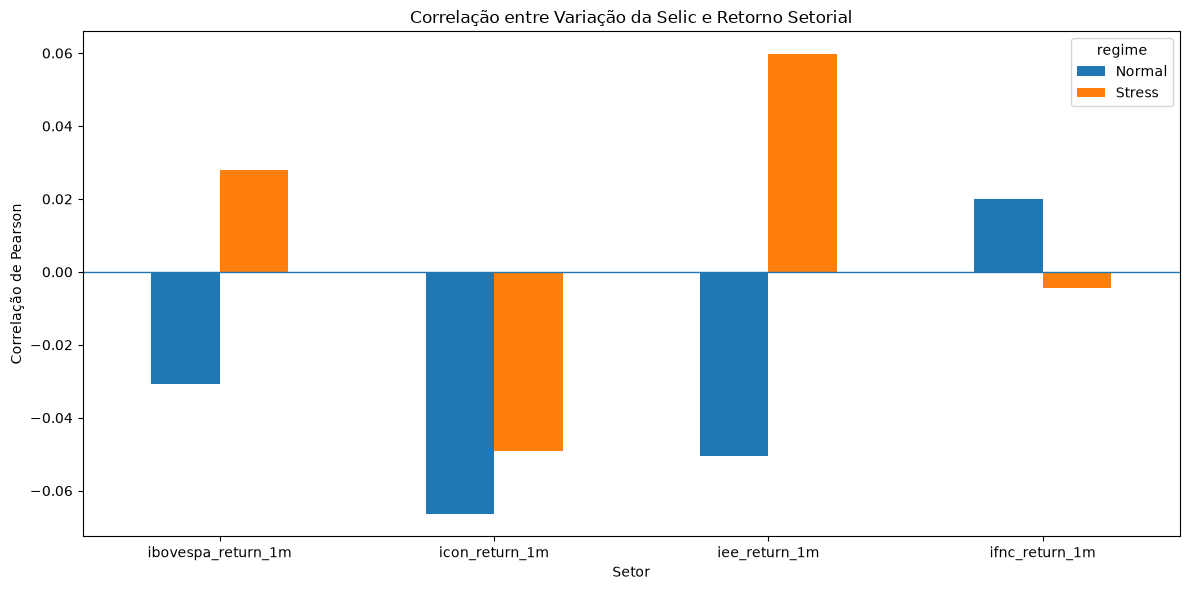

In [28]:
# ============================================================
# 15.1 EXEMPLO VISUAL — SELIC
# ============================================================

if not regime_correlations.empty and "selic_change" in available_macro:
    selic_corr = regime_correlations[
        regime_correlations["macro"] == "selic_change"
    ]

    if not selic_corr.empty:
        pivot_selic = selic_corr.pivot(
            index="setor",
            columns="regime",
            values="pearson"
        )
        display(pivot_selic)

        plot_cols = [c for c in ["Normal", "Stress"] if c in pivot_selic.columns]
        if plot_cols:
            pivot_selic[plot_cols].plot(kind="bar", figsize=(12, 6))
            plt.axhline(0, linewidth=1)
            plt.title("Correlação entre Variação da Selic e Retorno Setorial")
            plt.ylabel("Correlação de Pearson")
            plt.xlabel("Setor")
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
else:
    print("Correlação de Selic por regime não disponível para visualização.")


### Interpretação

A comparação entre regimes permite verificar se as relações observadas no período completo permanecem estáveis durante momentos de estresse.

Mudanças relevantes entre Normal e Stress podem indicar que determinados setores possuem maior sensibilidade às condições macroeconômicas justamente nos períodos mais críticos.


## 16. Outliers e eventos econômicos

Outliers financeiros não devem ser automaticamente removidos.

Em um estudo sobre resiliência, movimentos extremos podem representar justamente os eventos que queremos compreender.

Nesta etapa identificamos meses com retornos setoriais excepcionalmente positivos ou negativos utilizando o critério do intervalo interquartil (IQR).

Posteriormente relacionamos esses eventos ao Stress Score exploratório para verificar se movimentos extremos ocorreram com maior frequência durante períodos de estresse.


In [29]:
# ============================================================
# 16. OUTLIERS COMO EVENTOS ECONÔMICOS
# ============================================================

outlier_frames = []

for sector in available_sectors:
    series = ref_eda[sector].dropna()
    if series.empty:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (ref_eda[sector] < lower_bound) | (ref_eda[sector] > upper_bound)
    temp = ref_eda.loc[mask, ["date", sector]].copy()
    temp["setor"] = sector
    temp["tipo"] = np.where(
        temp[sector] < lower_bound,
        "Perda extrema",
        "Ganho extremo"
    )
    outlier_frames.append(temp.rename(columns={sector: "retorno"}))

if outlier_frames:
    outlier_events = pd.concat(outlier_frames, ignore_index=True)
    outlier_events = outlier_events.merge(
        stress_data[["date", "stress_score"]], on="date", how="left"
    )
    outlier_events = outlier_events.merge(
        analysis_regime[["date", "regime_eda"]], on="date", how="left"
    )
    outlier_events = outlier_events.sort_values("date")
    display(outlier_events)
else:
    outlier_events = pd.DataFrame(
        columns=["date", "retorno", "setor", "tipo", "stress_score", "regime_eda"]
    )
    print("Nenhum outlier foi identificado nas séries disponíveis.")


,date,retorno,setor,tipo,stress_score,regime_eda
0,2016-03-31,0.1697,ibovespa_return_1m,Ganho extremo,0.7682,Stress
2,2016-03-31,0.2334,ifnc_return_1m,Ganho extremo,0.7682,Stress
7,2016-07-31,0.1952,iee_return_1m,Ganho extremo,0.4184,Stress
8,2018-10-31,0.1587,iee_return_1m,Ganho extremo,-0.3565,Normal
1,2020-03-31,-0.2990,ibovespa_return_1m,Perda extrema,0.8271,Stress
3,2020-03-31,-0.3263,ifnc_return_1m,Perda extrema,0.8271,Stress
4,2020-03-31,-0.3151,icon_return_1m,Perda extrema,0.8271,Stress
9,2020-03-31,-0.2370,iee_return_1m,Perda extrema,0.8271,Stress
5,2020-04-30,0.1767,icon_return_1m,Ganho extremo,0.5466,Stress
6,2023-11-30,0.1633,icon_return_1m,Ganho extremo,-0.4267,Normal


### 16.1 Resumo dos eventos extremos

Nesta tabela verificamos quantos eventos extremos ocorreram em cada setor e qual era o nível de estresse socioeconômico observado nesses meses.


In [30]:
# ============================================================
# 16.1 RESUMO DOS EVENTOS EXTREMOS
# ============================================================

if outlier_events.empty:
    outlier_summary = pd.DataFrame()
    print("Não há eventos extremos para resumir.")
else:
    outlier_summary = (
        outlier_events
        .groupby("setor")
        .agg(
            eventos=("retorno", "count"),
            stress_medio=("stress_score", "mean"),
            stress_maximo=("stress_score", "max"),
            percentual_stress=("regime_eda", lambda x: x.eq("Stress").mean() * 100)
        )
        .reset_index()
    )
    display(outlier_summary.sort_values("percentual_stress", ascending=False))


,setor,eventos,stress_medio,stress_maximo,percentual_stress
0,ibovespa_return_1m,2,0.7976,0.8271,100.0000
3,ifnc_return_1m,2,0.7976,0.8271,100.0000
1,icon_return_1m,3,0.3156,0.8271,66.6667
2,iee_return_1m,3,0.2963,0.8271,66.6667


### Interpretação

Os outliers representam potenciais eventos de mercado relevantes para a análise de resiliência.

Uma concentração de perdas extremas em períodos classificados como Stress pode reforçar a relação entre condições macroeconômicas adversas e comportamento setorial.

Por outro lado, setores que apresentam menor frequência de perdas extremas durante Stress podem constituir candidatos a maior resiliência.


## 17. Sazonalidade e comparação entre subperíodos

Nesta etapa investigamos dois aspectos complementares:

1. Se existe algum padrão sistemático de comportamento dos setores ao longo dos meses do ano;
2. Se o comportamento de retorno e risco permanece semelhante em diferentes subperíodos históricos.

A sazonalidade possui caráter complementar na análise, enquanto a comparação entre subperíodos permite verificar a estabilidade dos resultados ao longo do tempo.


In [31]:
# ============================================================
# 17. SAZONALIDADE
# ============================================================

seasonal_data = ref_eda.copy()

seasonal_data["mes"] = (
    seasonal_data["date"].dt.month
)

seasonal_summary = (
    seasonal_data
    .groupby("mes")[available_sectors]
    .mean()
)

display(seasonal_summary)


,ibovespa_return_1m,ifnc_return_1m,icon_return_1m,iee_return_1m
mes,,,,
1,0.0240,0.0412,0.0125,0.0206
2,-0.0000,0.0084,-0.0136,0.0084
3,0.0004,0.0107,-0.0056,0.0106
4,0.0161,0.0104,0.0219,0.0331
5,-0.0231,-0.0175,-0.0003,0.0040
6,0.0045,0.0112,0.0058,0.0195
7,0.0307,0.0298,0.0264,0.0292
8,0.0088,0.0088,0.0088,-0.0101
9,-0.0027,-0.0115,-0.0021,-0.0112


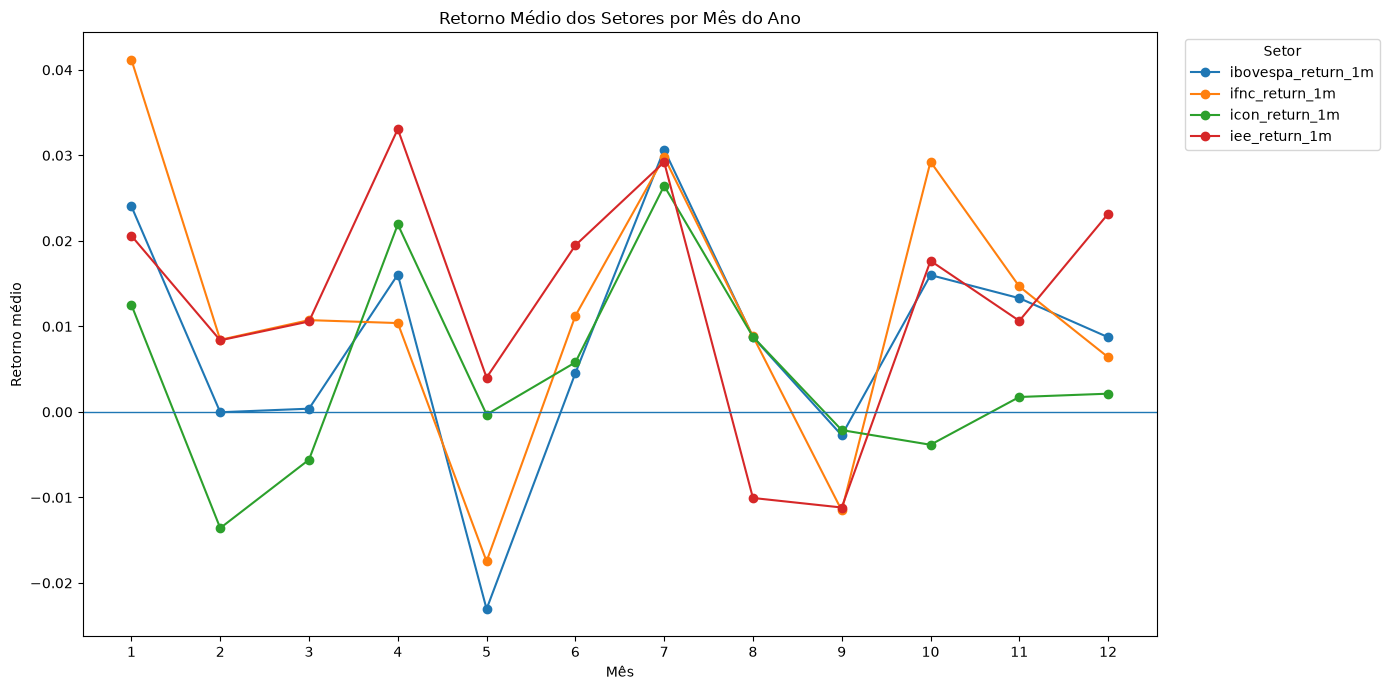

In [32]:
# ============================================================
# 17.1 GRÁFICO DE SAZONALIDADE
# ============================================================

seasonal_summary.plot(
    figsize=(14, 7),
    marker="o"
)

plt.title(
    "Retorno Médio dos Setores por Mês do Ano"
)
plt.xlabel("Mês")
plt.ylabel("Retorno médio")
plt.xticks(range(1, 13))
plt.axhline(0, linewidth=1)
plt.legend(
    title="Setor",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


### 17.2 Comparação entre subperíodos

A comparação por subperíodos permite verificar se as conclusões observadas para todo o histórico são consistentes ou se são fortemente influenciadas por determinados eventos.

Os períodos históricos definidos anteriormente são utilizados aqui como segmentos descritivos.


In [33]:
# ============================================================
# 17.2 COMPARAÇÃO ENTRE SUBPERÍODOS
# ============================================================

subperiod_rows = []

for period_name, (start_date, end_date) in periods.items():

    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)

    temp = ref_eda[
        (ref_eda["date"] >= start) &
        (ref_eda["date"] <= end)
    ].copy()

    for sector in available_sectors:

        if sector not in temp.columns:
            continue

        series = temp[sector].dropna()

        if series.empty:
            continue

        subperiod_rows.append({
            "periodo": period_name,
            "setor": sector,
            "observacoes": len(series),

            "retorno_medio_mensal": series.mean(),
            "mediana_retorno": series.median(),

            "retorno_acumulado": (
                (1 + series).prod() - 1
            ),

            "volatilidade_mensal": series.std(),

            "meses_positivos_pct": (
                (series > 0).mean() * 100
            ),

            "meses_negativos_pct": (
                (series < 0).mean() * 100
            ),

            "melhor_mes": series.max(),
            "pior_mes": series.min()
        })


subperiod_summary = pd.DataFrame(
    subperiod_rows
)

display(
    subperiod_summary.sort_values(
        ["periodo", "setor"]
    )
)

,periodo,setor,observacoes,retorno_medio_mensal,mediana_retorno,retorno_acumulado,volatilidade_mensal,meses_positivos_pct,meses_negativos_pct,melhor_mes,pior_mes
16,2023 em diante,ibovespa_return_1m,44,0.0106,0.0131,0.5199,0.0475,56.8182,43.1818,0.1256,-0.0749
18,2023 em diante,icon_return_1m,44,-0.0001,0.0003,-0.0935,0.0667,50.0000,50.0000,0.1633,-0.1042
19,2023 em diante,iee_return_1m,44,0.0105,0.0102,0.4961,0.0512,63.6364,36.3636,0.1269,-0.0879
17,2023 em diante,ifnc_return_1m,44,0.0135,0.0045,0.6481,0.0660,59.0909,40.9091,0.1637,-0.1052
12,Inflação/juros 2021-2022,ibovespa_return_1m,24,-0.0020,0.0047,-0.0780,0.0537,54.1667,45.8333,0.0698,-0.1150
14,Inflação/juros 2021-2022,icon_return_1m,24,-0.0222,-0.0190,-0.4484,0.0675,37.5000,62.5000,0.0918,-0.1429
15,Inflação/juros 2021-2022,iee_return_1m,24,-0.0013,-0.0068,-0.0503,0.0429,41.6667,58.3333,0.0894,-0.0574
13,Inflação/juros 2021-2022,ifnc_return_1m,24,-0.0046,-0.0088,-0.1648,0.0768,45.8333,54.1667,0.1712,-0.1283
8,Pandemia 2020,ibovespa_return_1m,12,0.0101,0.0379,0.0292,0.1226,50.0000,50.0000,0.1590,-0.2990
10,Pandemia 2020,icon_return_1m,12,0.0090,0.0433,0.0081,0.1264,58.3333,41.6667,0.1767,-0.3151


In [34]:
# ============================================================
# 17.3 RISCO POR SUBPERÍODO
# ============================================================

risk_summary = []

for period_name, (start_date, end_date) in periods.items():

    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)

    temp = ref_eda[
        (ref_eda["date"] >= start) &
        (ref_eda["date"] <= end)
    ].copy()

    for sector in available_sectors:

        if sector not in temp.columns:
            continue

        series = temp[sector].dropna()

        if series.empty:
            continue

        risk_summary.append({
            "periodo": period_name,
            "setor": sector,
            "observacoes": len(series),
            "retorno_medio": series.mean(),
            "volatilidade": series.std(),
            "percentual_negativo": (
                (series < 0).mean() * 100
            ),
            "pior_mes": series.min()
        })

risk_summary = pd.DataFrame(risk_summary)

display(
    risk_summary.sort_values(
        ["periodo", "setor"]
    )
)

,periodo,setor,observacoes,retorno_medio,volatilidade,percentual_negativo,pior_mes
16,2023 em diante,ibovespa_return_1m,44,0.0106,0.0475,43.1818,-0.0749
18,2023 em diante,icon_return_1m,44,-0.0001,0.0667,50.0000,-0.1042
19,2023 em diante,iee_return_1m,44,0.0105,0.0512,36.3636,-0.0879
17,2023 em diante,ifnc_return_1m,44,0.0135,0.0660,40.9091,-0.1052
12,Inflação/juros 2021-2022,ibovespa_return_1m,24,-0.0020,0.0537,45.8333,-0.1150
14,Inflação/juros 2021-2022,icon_return_1m,24,-0.0222,0.0675,62.5000,-0.1429
15,Inflação/juros 2021-2022,iee_return_1m,24,-0.0013,0.0429,58.3333,-0.0574
13,Inflação/juros 2021-2022,ifnc_return_1m,24,-0.0046,0.0768,54.1667,-0.1283
8,Pandemia 2020,ibovespa_return_1m,12,0.0101,0.1226,50.0000,-0.2990
10,Pandemia 2020,icon_return_1m,12,0.0090,0.1264,41.6667,-0.3151


### Interpretação

A análise de subperíodos permite avaliar a estabilidade dos resultados.

Caso um setor apresente bom desempenho apenas em um período específico, sua aparente resiliência pode estar associada a características particulares daquele contexto.

Já um comportamento consistente em diferentes períodos de estresse constitui evidência exploratória mais forte para a hipótese de resiliência.


## 18. Índice exploratório de resiliência setorial

Nesta etapa consolidamos os principais indicadores observados durante os períodos classificados como Stress em um índice exploratório de resiliência.

O objetivo é criar uma visão comparativa entre os setores considerando simultaneamente:

- retorno médio durante Stress;
- volatilidade;
- frequência de meses negativos;
- pior retorno mensal;
- drawdown;
- velocidade de recuperação.


In [35]:
# ============================================================
# 18. ÍNDICE EXPLORATÓRIO DE RESILIÊNCIA
# ============================================================

stress_only = analysis_regime[
    analysis_regime["regime_eda"] == "Stress"
].copy()

resilience_base = []

for sector in available_sectors:

    if sector not in stress_only.columns:
        continue

    series = stress_only[sector].dropna()

    if len(series) == 0:
        continue

    resilience_base.append({
        "setor": sector,
        "observacoes_stress": len(series),
        "retorno_medio_stress": series.mean(),
        "volatilidade_stress": series.std(),
        "percentual_negativo_stress": (
            (series < 0).mean() * 100
        ),
        "pior_mes_stress": series.min()
    })

resilience_base = pd.DataFrame(
    resilience_base
)

display(resilience_base)


,setor,observacoes_stress,retorno_medio_stress,volatilidade_stress,percentual_negativo_stress,pior_mes_stress
0,ibovespa_return_1m,44,-0.0079,0.0825,52.2727,-0.2990
1,ifnc_return_1m,44,-0.0114,0.0930,56.8182,-0.3263
2,icon_return_1m,44,-0.0107,0.0788,56.8182,-0.3151
3,iee_return_1m,39,0.0038,0.0736,46.1538,-0.2370


### 18.1 Drawdown observado durante Stress

O drawdown mede quanto o índice está abaixo do maior valor histórico observado até aquele momento.

Como os meses classificados como Stress podem não ser consecutivos, não é correto montar uma série acumulada apenas juntando esses meses. Por isso, nesta versão usamos o drawdown histórico já calculado e verificamos o pior valor observado nos meses classificados como Stress.

Quanto menos negativo o drawdown, maior a preservação de valor observada durante os períodos adversos.


In [36]:
# ============================================================
# 18.1 DRAWDOWN OBSERVADO NOS MESES DE STRESS
# ============================================================
# Não reconstruímos uma série acumulada apenas com meses de Stress,
# porque esses meses podem não ser consecutivos. Em vez disso, usamos
# o drawdown histórico já calculado para cada índice e observamos o pior
# valor que ocorreu em meses classificados como Stress.

drawdown_stress = []

for sector in available_sectors:
    base_name = sector.replace("_return_1m", "")
    dd_col = f"{base_name}_drawdown"

    if dd_col not in analysis_regime.columns:
        continue

    temp = analysis_regime.loc[
        analysis_regime["regime_eda"] == "Stress",
        ["date", dd_col]
    ].dropna()

    if temp.empty:
        continue

    drawdown_stress.append({
        "setor": sector,
        "drawdown_stress": temp[dd_col].min()
    })

drawdown_stress = pd.DataFrame(drawdown_stress)

if not drawdown_stress.empty:
    resilience_base = resilience_base.merge(drawdown_stress, on="setor", how="left")
else:
    resilience_base["drawdown_stress"] = np.nan

display(resilience_base)


,setor,observacoes_stress,retorno_medio_stress,volatilidade_stress,percentual_negativo_stress,pior_mes_stress,drawdown_stress
0,ibovespa_return_1m,44,-0.0079,0.0825,52.2727,-0.2990,-0.4109
1,ifnc_return_1m,44,-0.0114,0.0930,56.8182,-0.3263,-0.3860
2,icon_return_1m,44,-0.0107,0.0788,56.8182,-0.3151,-0.5041
3,iee_return_1m,39,0.0038,0.0736,46.1538,-0.2370,-0.2638


### 18.2 Inclusão da velocidade de recuperação

A capacidade de recuperar perdas também é relevante para a definição de resiliência.

Nesta versão, o tempo de recuperação corresponde ao pior drawdown histórico de cada índice, e não exclusivamente a um episódio de Stress. Por isso, ele deve ser interpretado como um componente exploratório complementar do índice de resiliência.

Uma evolução futura pode calcular o tempo de recuperação separadamente para cada episódio contínuo de Stress.


In [37]:
# ============================================================
# 18.2 MERGE COM TEMPO DE RECUPERAÇÃO
# ============================================================
# recovery_table usa nomes de índices (IBOVESPA, IFNC, ICON, IEE),
# enquanto resilience_base usa nomes das colunas de retorno.
# Criamos uma chave comum antes do merge.

if "recovery_table" in globals() and not recovery_table.empty:
    recovery_for_resilience = recovery_table[[
        "indice", "meses_para_recuperar"
    ]].copy()

    recovery_for_resilience["setor"] = (
        recovery_for_resilience["indice"].str.lower() + "_return_1m"
    )

    recovery_for_resilience = recovery_for_resilience[[
        "setor", "meses_para_recuperar"
    ]].rename(columns={
        "meses_para_recuperar": "tempo_recuperacao"
    })

    resilience_base = resilience_base.merge(
        recovery_for_resilience,
        on="setor",
        how="left"
    )
else:
    resilience_base["tempo_recuperacao"] = np.nan

display(resilience_base)


,setor,observacoes_stress,retorno_medio_stress,volatilidade_stress,percentual_negativo_stress,pior_mes_stress,drawdown_stress,tempo_recuperacao
0,ibovespa_return_1m,44,-0.0079,0.0825,52.2727,-0.2990,-0.4109,60.0000
1,ifnc_return_1m,44,-0.0114,0.0930,56.8182,-0.3263,-0.3860,48.0000
2,icon_return_1m,44,-0.0107,0.0788,56.8182,-0.3151,-0.5041,NaN
3,iee_return_1m,39,0.0038,0.0736,46.1538,-0.2370,-0.2638,11.0000


### 18.3 Normalização dos indicadores

Os indicadores possuem escalas diferentes e, por isso, são transformados para uma escala comparável entre 0 e 1 usando normalização Min-Max entre os setores analisados.

Para os componentes do índice exploratório, adotamos:

- maior retorno médio em Stress = melhor;
- menor volatilidade em Stress = melhor;
- menor frequência de meses negativos = melhor;
- pior mês menos negativo = melhor;
- drawdown menos negativo = melhor;
- menor tempo de recuperação = melhor.

Os scores são **relativos aos setores presentes na amostra**. Um score de 100 não significa ausência de risco; significa apenas melhor posição relativa dentro dos critérios e setores comparados.


In [38]:
# ============================================================
# 18.3 NORMALIZAÇÃO
# ============================================================

def minmax_score(series, higher_is_better=True):

    series = series.astype(float)

    min_value = series.min()
    max_value = series.max()

    if pd.isna(min_value) or pd.isna(max_value):
        return pd.Series(
            np.nan,
            index=series.index
        )

    if max_value == min_value:
        return pd.Series(
            1.0,
            index=series.index
        )

    score = (
        (series - min_value) /
        (max_value - min_value)
    )

    if not higher_is_better:
        score = 1 - score

    return score


resilience_base["score_retorno"] = (
    minmax_score(
        resilience_base["retorno_medio_stress"],
        higher_is_better=True
    )
)

resilience_base["score_volatilidade"] = (
    minmax_score(
        resilience_base["volatilidade_stress"],
        higher_is_better=False
    )
)

resilience_base["score_perdas"] = (
    minmax_score(
        resilience_base["percentual_negativo_stress"],
        higher_is_better=False
    )
)

resilience_base["score_pior_mes"] = (
    minmax_score(
        resilience_base["pior_mes_stress"],
        higher_is_better=True
    )
)

resilience_base["score_drawdown"] = (
    minmax_score(
        resilience_base["drawdown_stress"],
        higher_is_better=True
    )
)

resilience_base["score_recuperacao"] = (
    minmax_score(
        resilience_base["tempo_recuperacao"],
        higher_is_better=False
    )
)


### 18.4 Cálculo do Índice

O índice final é calculado pela média simples dos componentes normalizados disponíveis. Todos os componentes recebem o mesmo peso nesta versão exploratória.

O resultado é convertido para uma escala de 0 a 100 para facilitar a comparação.

Quanto maior o valor, maior a resiliência **relativa** observada segundo os critérios adotados. Esse índice ainda não é uma métrica financeira padrão e não deve ser interpretado como recomendação de investimento. Os pesos e componentes precisam ser validados em etapas futuras.


In [39]:
# ============================================================
# 18.4 ÍNDICE FINAL
# ============================================================

score_columns = [
    "score_retorno",
    "score_volatilidade",
    "score_perdas",
    "score_pior_mes",
    "score_drawdown",
    "score_recuperacao"
]

resilience_base["resilience_score"] = (
    resilience_base[score_columns]
    .mean(axis=1, skipna=True)
)

resilience_base["resilience_score_100"] = (
    resilience_base["resilience_score"] * 100
)

resilience_ranking = (
    resilience_base
    .sort_values(
        "resilience_score_100",
        ascending=False
    )
    .reset_index(drop=True)
)

resilience_ranking["ranking"] = (
    resilience_ranking.index + 1
)

display(
    resilience_ranking[
        [
            "ranking",
            "setor",
            "observacoes_stress",
            "retorno_medio_stress",
            "volatilidade_stress",
            "percentual_negativo_stress",
            "pior_mes_stress",
            "drawdown_stress",
            "tempo_recuperacao",
            "resilience_score_100"
        ]
    ]
)


,ranking,setor,observacoes_stress,retorno_medio_stress,volatilidade_stress,percentual_negativo_stress,pior_mes_stress,drawdown_stress,tempo_recuperacao,resilience_score_100
0,1,iee_return_1m,39,0.0038,0.0736,46.1538,-0.2370,-0.2638,11.0000,100.0000
1,2,ibovespa_return_1m,44,-0.0079,0.0825,52.2727,-0.2990,-0.4109,60.0000,31.5178
2,3,icon_return_1m,44,-0.0107,0.0788,56.8182,-0.3151,-0.5041,NaN,17.9925
3,4,ifnc_return_1m,44,-0.0114,0.0930,56.8182,-0.3263,-0.3860,48.0000,12.2683


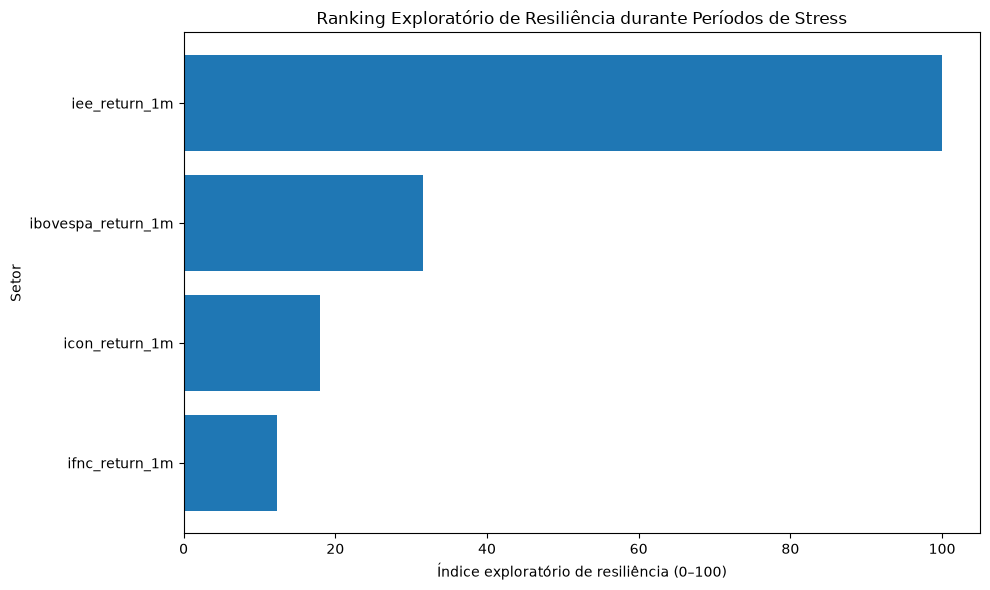

In [40]:
# ============================================================
# 18.5 VISUALIZAÇÃO DO RANKING
# ============================================================

plot_data = (
    resilience_ranking
    .sort_values(
        "resilience_score_100",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["setor"],
    plot_data["resilience_score_100"]
)

plt.xlabel(
    "Índice exploratório de resiliência (0–100)"
)

plt.ylabel("Setor")

plt.title(
    "Ranking Exploratório de Resiliência durante Períodos de Stress"
)

plt.tight_layout()
plt.show()


### 18.6 Interpretação e conexão com o problema de pesquisa

O ranking sintetiza as principais evidências obtidas durante a EDA.

Setores com maior pontuação apresentam, dentro dos critérios adotados, uma combinação mais favorável de retorno, risco, perdas e recuperação durante períodos classificados como Stress.

Entretanto, o Índice deve ser interpretado como uma ferramenta exploratória e não como uma conclusão definitiva de resiliência.

Os resultados serão utilizados para orientar as próximas etapas do projeto, especialmente:

- definição das variáveis utilizadas no modelo;
- construção de features defasadas;
- definição e comparação de diferentes estratégias para classificação de períodos de Stress;
- avaliação da capacidade preditiva dos modelos;
- comparação entre setores em diferentes cenários econômicos.

Importante: o `resilience_score_100` não deve ser utilizado como target do modelo de Machine Learning. Ele representa uma síntese exploratória construída a partir dos próprios indicadores analisados na EDA.


## 19. Volume disponível para Machine Learning

O número de linhas não é a única questão. Também importa quantas features serão usadas, quanto histórico cada uma possui e, futuramente, quantos meses serão rotulados como `stress` e `normal`.

Nesta etapa ainda não existe o target `stress`, então não é possível avaliar o balanceamento das classes.

In [41]:
initial_feature_set = [c for c in [
    "ibc_br_change", "selic", "selic_change", "usd_brl_return", "usd_brl_volatility",
    "ipca_12m", "pib_change_3m", "unemployment", "unemployment_change"
] if c in mvp_eda.columns]

regime_ready = mvp_eda[["date"] + initial_feature_set].dropna()
all_market_ready = ref_eda[["date"] + sector_cols].dropna()

volume = pd.DataFrame([
    {
        "dataset": "MVP completo (todas core)",
        "linhas": len(complete_eda),
        "features/series": 11,
        "inicio": complete_eda["date"].min(),
        "fim": complete_eda["date"].max(),
    },
    {
        "dataset": "Features iniciais de regime",
        "linhas": len(regime_ready),
        "features/series": len(initial_feature_set),
        "inicio": regime_ready["date"].min(),
        "fim": regime_ready["date"].max(),
    },
    {
        "dataset": "Todos os índices B3",
        "linhas": len(all_market_ready),
        "features/series": len(sector_cols),
        "inicio": all_market_ready["date"].min(),
        "fim": all_market_ready["date"].max(),
    },
])
display(volume)

print("Features candidatas ao primeiro modelo:")
print(initial_feature_set)
print("\nObservações completas nessas features:", len(regime_ready))
print("Target 'stress' existe no dataset?", "stress" in mvp_eda.columns)

,dataset,linhas,features/series,inicio,fim
0,MVP completo (todas core),139,11,2015-01-31,2026-07-31
1,Features iniciais de regime,167,9,2012-09-30,2026-07-31
2,Todos os índices B3,140,4,2015-01-31,2026-08-31


Features candidatas ao primeiro modelo:
['ibc_br_change', 'selic', 'selic_change', 'usd_brl_return', 'usd_brl_volatility', 'ipca_12m', 'pib_change_3m', 'unemployment', 'unemployment_change']

Observações completas nessas features: 167
Target 'stress' existe no dataset? False


## 20. Dataset de regime x dataset de resiliência

A EDA permite avaliar uma separação importante:

- **Dataset de regime**: features macroeconômicas e socioeconômicas para classificar `stress/normal`.
- **Dataset de resiliência**: índices B3 e métricas de retorno, volatilidade e drawdown para comparar os setores.

Essa divisão evita perder histórico macroeconômico só porque um índice setorial possui menos dados e também deixa mais claro o papel de cada variável.

In [42]:
regime_cols = ["date"] + initial_feature_set
resilience_cols = ["date"] + [c for c in ref_eda.columns if any(c.startswith(p) for p in ["ibovespa", "ifnc", "icon", "iee"])]

regime_dataset_preview = mvp_eda[regime_cols].dropna().copy()
resilience_dataset_preview = ref_eda[resilience_cols].dropna(subset=sector_cols).copy()

print("Dataset de regime (preview):", regime_dataset_preview.shape)
print(regime_dataset_preview["date"].min(), "->", regime_dataset_preview["date"].max())
print("Dataset de resiliência (preview):", resilience_dataset_preview.shape)
print(resilience_dataset_preview["date"].min(), "->", resilience_dataset_preview["date"].max())

Dataset de regime (preview): (167, 10)
2012-09-30 00:00:00 -> 2026-07-31 00:00:00
Dataset de resiliência (preview): (140, 21)
2015-01-31 00:00:00 -> 2026-08-31 00:00:00


## 21. Resumo automático dos principais achados

O bloco abaixo não substitui a interpretação. Ele resume alguns fatos objetivos para facilitar a documentação da entrega.

In [43]:
# Cobertura mais limitante entre as principais séries.
core_for_coverage = [c for c in macro_cols + sector_cols if c in coverage["variavel"].values]
core_cov = coverage[coverage["variavel"].isin(core_for_coverage)].sort_values("observacoes")
limiting = core_cov.iloc[0]

# ============================================================
# Drawdown dos índices
# ============================================================

dd_df = recovery_table[
    [
        "indice",
        "pior_drawdown",
        "data_pior_drawdown"
    ]
].copy()

# Drawdown mais negativo = maior queda
worst_sector = dd_df.loc[
    dd_df["pior_drawdown"].idxmin()
]

# Drawdown mais próximo de zero = menor pior queda
best_sector = dd_df.loc[
    dd_df["pior_drawdown"].idxmax()
]

print(f"Período da EDA: {ref_eda['date'].min().date()} a {ref_eda['date'].max().date()}")
print(f"Variável core com menor cobertura: {limiting['variavel']} ({int(limiting['observacoes'])} observações)")
print(f"Observações completas nas features iniciais de regime: {len(regime_ready)}")
print(f"Observações com todos os índices B3: {len(all_market_ready)}")
print(f"Maior queda observada entre os drawdowns: {worst_sector['indice']} = {worst_sector['pior_drawdown']:.2%}")
print(f"Menor pior-drawdown entre os índices comparados: {best_sector['indice']} = {best_sector['pior_drawdown']:.2%}")

Período da EDA: 2012-01-31 a 2026-08-31
Variável core com menor cobertura: iee (140 observações)
Observações completas nas features iniciais de regime: 167
Observações com todos os índices B3: 140
Maior queda observada entre os drawdowns: ICON = -57.43%
Menor pior-drawdown entre os índices comparados: IEE = -26.38%


## 22. Hipóteses para a próxima etapa

As hipóteses abaixo devem ser confirmadas ou descartadas usando os resultados apresentados nas células anteriores:

1. A volatilidade cambial pode aumentar em períodos em que os índices também apresentam maior risco.
2. IFNC, ICON e IEE podem responder de formas diferentes a mudanças na Selic.
3. ICON pode apresentar maior sensibilidade a deterioração de atividade econômica e mercado de trabalho.
4. A combinação de inflação alta, juros altos, câmbio e desaceleração pode ser mais útil para identificar regimes do que uma única variável isolada.
5. Retorno, volatilidade e drawdown devem ser analisados em conjunto antes de classificar um setor como resiliente.

Estas são hipóteses exploratórias, não conclusões causais.

## 23. Limitações identificadas

Pontos que devem ser considerados na próxima fase:

- frequência mensal reduz o número de observações;
- observações de séries temporais não são totalmente independentes;
- diferentes séries possuem coberturas históricas diferentes;
- PIB é trimestral e precisa de tratamento temporal;
- lags usados no MVP são aproximações conservadoras das datas reais de divulgação;
- são analisados apenas três índices setoriais na primeira versão;
- o target `stress` ainda precisa ser definido e documentado;
- modelos complexos podem sofrer overfitting com esse volume de dados.

A futura validação deve respeitar a ordem temporal, evitando um `train_test_split` aleatório comum.

## 24. Próximos passos

Depois desta EDA, a sequência sugerida é:

1. revisar os insights e anomalias encontradas;
2. definir formalmente o critério de `stress = 0/1`;
3. verificar a quantidade de meses em cada classe;
4. fechar o conjunto inicial de features;
5. criar um baseline;
6. testar Logistic Regression;
7. comparar com Random Forest controlando a complexidade;
8. usar validação temporal;
9. aplicar os regimes identificados à análise de IFNC, ICON e IEE;
10. construir uma medida/ranking de resiliência.